# Lab 06: 如何做出一個有用的預警系統，在異常事件發生之前就發出警告

難點在於兩個長得一樣的時間點，企業簡訊的對外出口 `port-id7427`,連續兩個晚上都在 20:00 開始爬升:

- **2/25 那一晚**,爬升到容量的 86% 就停住，什麼事都沒有
- **2/26 那一晚**,一路爬升到 01:05 超出容量，下單回報跟著延遲

**兩條爬坡在圖上長得幾乎一樣，但只有一晚是真正的異常事件。** 所以 lab06 有以下兩個目標

- **在 2/25 整晚一次都不預警**
- **在 2/26 越線之前就發出通知**,而且越早越好

接下來就會一步一步照著下面的步驟前進，來達成我們的目標:

```mermaid
flowchart LR
    N1["看資料<br/>做得了預警嗎<br/>平常什麼規律"] --> N2["主模型 Prophet<br/>這個時刻的正常是多少"] --> N3["殘差模型 XGBoost<br/>不正常往哪裡走<br/>合成預警規則"] --> N4["驗證<br/>這套規則能不能上場"]
```

<p align="center"><img src="slides/u07_pipeline.png" width="80%" alt="單元 07 的時間序列預測概念流程圖: 原始資料先分解出可預期的結構，取殘差，做滑動視窗，餵預測模型，最後判斷會不會跨過門檻"></p>

---
## 接下來會以 port 7429 **容量耗盡**示範


#### 資料是 Lab 00 到 02 那份的擴充版

- 新檔案在原本那 43,200 列上存在七個新事件，以及兩個 port 的固定排程背景 (`port-id7429` 每個交易日的開盤微爆與收盤集合競價、`port-id7431` 每天晚上的日終對帳)。
- **換檔案的理由: 原本那份資料裡的事件沒有可以外推的那一段。** 原本的資料是階梯不是斜坡。**預警要成立，前提是跨線之前資料裡就有一段走勢**

<p align="center"><img src="slides/u07_warning_scenarios.png" width="80%" alt="單元 07 的常見預警情境投影片: 容量耗盡、業務需求尖峰、服務品質劣化、硬體老化與環境風險等情境，各自對應不同的預警目標與風險判讀"></p>



---

## 載入套件


In [1]:
# 🎯 載入套件、設定中文字型、找到課程資料的位置，並確認 Prophet 裝得起來。
#    每次重新打開 notebook 都要先跑這一格，後面才有 pd、np、DATA_SYNTHETIC 這些名字可以用。
from pathlib import Path
import base64, io, warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm
from scipy import stats
from IPython.display import display, HTML

# ============ ⚙️ 可調參數 ============
# CJK_CANDIDATES: 圖上的中文用哪一套字型，由左到右試，用第一個裝得到的。
#                 一個都沒裝到不影響任何數字，只會讓圖上的中文變方框。
CJK_CANDIDATES = ["PingFang TC", "PingFang HK", "Heiti TC", "Arial Unicode MS",   # macOS
                  "Microsoft JhengHei", "Microsoft YaHei",                        # Windows
                  "Noto Sans CJK TC", "Noto Sans TC", "Source Han Sans TW",       # Linux
                  "WenQuanYi Zen Hei", "Droid Sans Fallback"]
ACC, GREY, INK = "tab:red", "0.55", "0.25"    # 全書配色: 一個強調色，其餘一律走灰階
# ====================================

# ---- 1. 關掉套件的雜訊訊息，統一圖與表的外觀 ----
warnings.filterwarnings("ignore")
for _name in ("cmdstanpy", "prophet", "stan"):     # Prophet 透過 cmdstanpy 配適，它的 log 很長
    _lg = logging.getLogger(_name)
    _lg.setLevel(logging.CRITICAL)
    _lg.handlers.clear(); _lg.addHandler(logging.NullHandler()); _lg.propagate = False
plt.style.use("seaborn-v0_8-whitegrid")
_installed = {f.name for f in _fm.fontManager.ttflist}
CJK_FONT = next((f for f in CJK_CANDIDATES if f in _installed), None)
if CJK_FONT:
    plt.rcParams["font.sans-serif"] = [CJK_FONT] + plt.rcParams["font.sans-serif"]
    logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams["axes.unicode_minus"] = False        # 用 ASCII 的減號，中文字型才畫得出負號
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 200)


# ---- 2. 這一本每一張圖都用這個函式顯示 ----
#         notebook 直接 display(fig) 會靠左，所以統一轉成 <img> 再置中。
def show_fig(fig, width="80%"):
    """把圖存成 PNG，再以 80% 寬度置中顯示，然後關掉它。

    直接 display(fig) 會靠左，寬度也只由 figsize 決定; 轉成 <img> 才控制得了寬度與置中。
    """
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=fig.dpi, bbox_inches="tight")
    plt.close(fig)
    src = "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode("ascii")
    display(HTML(f'<div style="text-align: center">'
                 f'<img src="{src}" style="width: {width}"></div>'))


# ---- 3. 檔案放在哪一層 ----
#         從 notebook 自己的位置往上一層一層找，第一個看得到 data/synthetic 的就是根目錄。
NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR
while (PROJECT_ROOT != PROJECT_ROOT.parent
       and not (PROJECT_ROOT / "data" / "synthetic").is_dir()
       and not (PROJECT_ROOT / "environments").is_dir()):
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_SYNTHETIC = PROJECT_ROOT / "data" / "synthetic"       # 課程資料放這裡 (只讀不寫)
DATA_PROCESSED = PROJECT_ROOT / "outputs" / "workshop"     # 這一套教材算完的結果寫這裡
if not (DATA_SYNTHETIC / "synthetic_rrd_metrics_week6.csv").exists():
    raise FileNotFoundError(
        f"找不到課程資料 {DATA_SYNTHETIC / 'synthetic_rrd_metrics_week6.csv'}\n"
        f"目前所在資料夾是 {NB_DIR}\n"
        "請關掉 JupyterLab，改成在 week6 這個資料夾裡重新打開它，再開這本 notebook。")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# ---- 4. Prophet 是這一本的主模型 ----
#         這一格不會因為缺它而中斷 (「及格線」那一格不需要它)，之後每一格才需要。
try:
    from prophet import Prophet
    HAS_PROPHET = True
except Exception:
    HAS_PROPHET = False

display(pd.DataFrame([
    ("repo 根目錄", str(PROJECT_ROOT)),
    ("中文字型", CJK_FONT if CJK_FONT else "找不到，圖上的中文會變成方框"),
    ("Prophet", "已就緒" if HAS_PROPHET else
     "找不到。及格線那一格仍然跑得動，之後每一格都需要它。"
     "裝法看 1_pkg_checker.ipynb。"),
], columns=["環境", "狀態"]))


,環境,狀態
0,repo 根目錄,E:\桌面\agent_os\database\NTU_POLab\AIAxMitake\github_code\aiops-anomaly-zero-to-hero\week6
1,中文字型,Microsoft JhengHei
2,Prophet,已就緒


---

## 載入資料


In [2]:
# 🎯 讀 Week 6 專屬資料集，換算成有語意的欄位 (同 Lab 01)，並列出事件目錄。

# ============ ⚙️ 可調參數 ============
TARGET = "traffic_total"        # 預測目標: 雙向總流量 (bytes / 5 分鐘)。這一章示範的是容量耗盡
PRIMARY_PORT = "port-id7427"    # 示範 port: 事件 K 注入在它身上，有完整的「先爬升、後越線」
# 三個時間切點。TRAIN_END 是訂告警規則的上限 (事件 K 之前就凍結);
# ACC_TRAIN_END 到 ACC_TEST_END 是評估預測精度的 holdout，整段落在事件之外。
TRAIN_END = pd.Timestamp("2026-02-24")
ACC_TRAIN_END = pd.Timestamp("2026-02-21")
ACC_TEST_END = pd.Timestamp("2026-02-24")
# 容量門檻 T = 訓練期第 CAP_Q 百分位 x CAP_MULT。調高: 碰到 T 的次數變少，但要更晚才發現;
# 調低: 日常尖峰就會頻繁碰到它。
CAP_Q, CAP_MULT = 0.97, 1.05
# ====================================
STEPS_PER_DAY = 288          # 一天 288 格。5 分鐘一列換算出來的，換取樣間隔才要動


# ---- 1. 特徵工程: 從 RRD 累積計數器算出語意特徵 (同 Lab 01) ----
#         只做兩種事: 把 in 與 out 兩個方向加起來變成總量，以及把壞掉的封包數換成比率。
def build_features(df):
    df = df.sort_values(["port_id", "timestamp"]).reset_index(drop=True)
    sdiv = lambda a, b: np.where(b > 0, a / b, 0.0)    # 分母是 0 的格子直接給 0，不要變成 inf
    df["traffic_total"]   = df["INOCTETS"] + df["OUTOCTETS"]
    df["ucast_total"]     = df["INUCASTPKTS"] + df["OUTUCASTPKTS"]
    df["broadcast_total"] = df["INBROADCASTPKTS"] + df["OUTBROADCASTPKTS"]
    df["multicast_total"] = df["INMULTICASTPKTS"] + df["OUTMULTICASTPKTS"]
    df["errors_total"]    = df["INERRORS"] + df["OUTERRORS"]
    df["discards_total"]  = df["INDISCARDS"] + df["OUTDISCARDS"]
    # 比率一律以 unicast 封包數當分母，忙碌與空閒的時段才互相比得起來。
    df["error_rate"]      = sdiv(df["errors_total"], df["ucast_total"])
    df["discard_rate"]    = sdiv(df["discards_total"], df["ucast_total"])
    df["unknown_total"]   = df["INUNKNOWNPROTOS"]
    df["avg_packet_size"] = sdiv(df["traffic_total"], df["ucast_total"])
    # 每 KB 流量帶幾個封包。它是 avg_packet_size 的倒數，但預警要讀的正是這個方向:
    # 「封包數漲了、位元組沒跟著漲」會讓它往上，而那就是派送前工單入列的形狀。
    df["pkts_per_kb"]     = sdiv(df["ucast_total"] * 1000.0, df["traffic_total"])
    return df


# ---- 2. 讀三個檔 ----
#         指標是每 5 分鐘一列的量測值; 事件目錄是事後整理的標準答案，不進模型;
#         排程行事曆是事前公告過而且會重複發生的活動，它才是 h(t) 的合法輸入。
raw = pd.read_csv(DATA_SYNTHETIC / "synthetic_rrd_metrics_week6.csv", parse_dates=["timestamp"])
features = build_features(raw)
event_catalog = pd.read_csv(DATA_SYNTHETIC / "synthetic_event_catalog_week6.csv",
                            parse_dates=["start_time", "end_time"])
schedule = pd.read_csv(DATA_SYNTHETIC / "synthetic_scheduled_calendar_week6.csv",
                       parse_dates=["start_time", "end_time"])

# ---- 3. 每個 port 一條容量門檻，只用訓練期的資料訂 ----
CAPACITY = {pid: float(g.loc[g.timestamp < TRAIN_END, TARGET].quantile(CAP_Q) * CAP_MULT)
            for pid, g in features.groupby("port_id")}

display(event_catalog[["event_id", "event_type", "port_id", "start_time", "end_time", "description"]])


,event_id,event_type,port_id,start_time,end_time,description
0,A,business_traffic_growth,port-id7430,2026-02-04 09:00:00,2026-02-04 10:55:00,正常業務流量增加
1,B,small_packet_scan,port-id7428,2026-02-06 13:10:00,2026-02-06 13:55:00,大量小封包 / 掃描
2,C,large_file_backup,port-id7431,2026-02-08 01:00:00,2026-02-08 03:55:00,大檔案傳輸 / 備份
3,D,queue_congestion,port-id7427,2026-02-11 15:20:00,2026-02-11 16:25:00,頻寬壅塞 / Queue 滿
4,E,link_quality_issue,port-id7429,2026-02-14 10:35:00,2026-02-14 11:10:00,線路品質問題
5,F,load_sensitive_link_issue,port-id7427,2026-02-17 16:00:00,2026-02-17 17:25:00,高負載下線路不穩
6,G,broadcast_storm,MULTI,2026-02-19 11:30:00,2026-02-19 12:25:00,Broadcast Storm / L2 Loop
7,H,multicast_flooding,MULTI,2026-02-22 20:05:00,2026-02-22 21:30:00,Multicast Flooding
8,I,abnormal_device_sender,port-id7430,2026-02-25 09:45:00,2026-02-25 11:00:00,異常設備大量發送
9,J,unknown_protocol_scan,port-id7428,2026-02-27 14:15:00,2026-02-27 15:00:00,Unknown Protocol


---

## 看資料: 這個 port 做得了預警嗎

```mermaid
flowchart LR
    N1["看資料<br/>做得了預警嗎<br/>平常什麼規律"] --> N2["主模型 Prophet<br/>這個時刻的正常是多少"] --> N3["殘差模型 XGBoost<br/>不正常往哪裡走<br/>合成預警規則"] --> N4["驗證<br/>這套規則能不能上場"]
    style N1 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

### 動手挑方法之前先回答一個問題: 資料可以拿來預警嗎？

- 在事情變嚴重之前，資料裡就已經有一段可以往前延伸的走勢
- 先把三個晚上疊在一起看: 一個什麼都沒發生的夜晚、一個流量有上升的趨勢但沒有異常事件的夜晚、還有實際發生異常事件的那一晚。



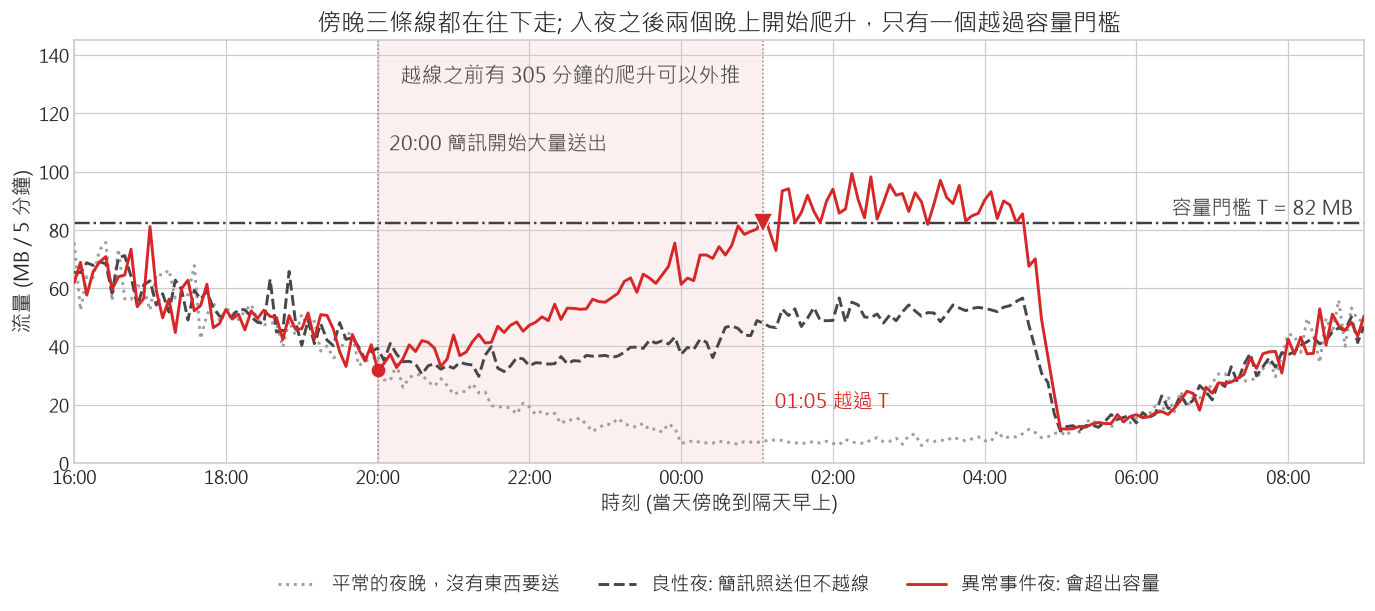

,20:00 起算 3 小時的斜率 (MB/小時),整晚最高 / T,越過 T,avg_packet_size 最低 (B)
night,,,,
2026-02-23 平常的夜晚，沒有東西要送,-7.03,92%,沒有,653
2026-02-25 良性夜: 簡訊照送但不越線,0.07,86%,沒有,231
2026-02-26 異常事件夜: 會超出容量,7.42,121%,01:05,233


In [3]:
# 🎯 三個晚上疊在同一條時鐘軸上: 正常的夜晚、良性的簡訊發送夜、發生異常事件的那一晚。
#     這個 port 是企業簡訊的對外出口，晚上爬升的那一段就是月結簡訊在大量送出。
import matplotlib.dates as mdates

# ============ ⚙️ 可調參數 ============
VIEW_START_HOUR = 16      # 每一張夜間圖從幾點開始畫 (當天 16:00)
VIEW_HOURS = 17           # 往後畫幾個小時 (畫到隔天 09:00)。三張夜間圖必須共用同一組值
SLOPE_HOURS = 3           # 「爬升得多快」量的是 20:00 起算幾個小時的平均斜率。
                          # 縮短: 一格雜訊就會改變斜率; 拉長: 會把越線之後那一段也算進來
# ====================================
RAMP_H = 20 - VIEW_START_HOUR                     # 20:00 在這條軸上的位置 (第 4 個小時)
CASE_DAY   = pd.Timestamp("2026-02-26")           # 事件 K 那一晚
CASE_START = pd.Timestamp("2026-02-26 20:00")     # 這一晚簡訊開始大量送出
T_CASE = CAPACITY[PRIMARY_PORT]                   # 這個 port 的容量門檻

# ---- 1. 把三個晚上換算到同一條「16:00 起算第幾個小時」的軸上，曲線才疊得起來 ----
#         起點拉到爬坡之前四小時，是為了讓「平常有多安靜」一起入鏡。
port_all = features[features.port_id == PRIMARY_PORT].set_index("timestamp").sort_index()
port_hist = port_all          # 後面幾格沿用這個名字

# 一列一個晚上: (日期, 圖例文字, 顏色, 線型)。只有異常事件那一晚用強調色與實線。
NIGHTS = [("2026-02-23", "平常的夜晚，沒有東西要送", "0.62", ":"),
          ("2026-02-25", "良性夜: 簡訊照送但不越線", "0.28", "--"),
          ("2026-02-26", "異常事件夜: 會超出容量", "tab:red", "-")]


def night_slice(day):
    """當天 16:00 起算 VIEW_HOURS 小時，並多算一欄 h = 從 16:00 起算第幾個小時。"""
    a = pd.Timestamp(day) + pd.Timedelta(hours=VIEW_START_HOUR)
    seg = port_all.loc[a:a + pd.Timedelta(hours=VIEW_HOURS)].copy()
    seg["h"] = (seg.index - a).total_seconds() / 3600.0
    return seg


# ---- 2. 圖上要標的每一個數字都從資料算出來，這一格不 print 任何句子 ----
#         白天的日間尖峰本來就會有單格碰到 T，所以「這一晚第一次越線」從 20:00 起算。
seg_k = night_slice(CASE_DAY)
hit = seg_k[(seg_k.h >= RAMP_H) & (seg_k[TARGET] >= T_CASE)]
h_ramp = (CASE_START - (CASE_DAY + pd.Timedelta(hours=VIEW_START_HOUR))).total_seconds() / 3600.0
h_cross = float(hit.h.iloc[0])
ramp_min = int(round((h_cross - h_ramp) * 60))      # 越線之前有幾分鐘的爬升可以外推
y_ramp = float(seg_k.loc[seg_k.h == h_ramp, TARGET].iloc[0]) / 1e6

# ---- 3. 畫圖。上緣多留 46% 的空白，爬升長度那句說明才不會壓到資料 ----
fig, ax = plt.subplots(figsize=(12.6, 5.8), dpi=110)
top = float(seg_k[TARGET].max()) / 1e6 * 1.46
ax.axvspan(h_ramp, h_cross, color="tab:red", alpha=0.07, zorder=0)
ax.axhline(T_CASE / 1e6, color="0.25", ls="-.", lw=1.6, zorder=1)
for day, lab, color, ls in NIGHTS:
    seg = night_slice(day)
    ax.plot(seg.h, seg[TARGET] / 1e6, color=color, ls=ls, lw=1.9, label=lab, zorder=3)
ax.plot([h_cross], [T_CASE / 1e6], marker="v", ms=13, color="tab:red", zorder=6,
        markeredgecolor="white", markeredgewidth=1.0)
ax.text(h_cross + 0.15, top * 0.13, f"{hit.index[0]:%H:%M} 越過 T",
        ha="left", fontsize=13, color="tab:red")
ax.text(VIEW_HOURS - 0.15, T_CASE / 1e6 + top * 0.02, f"容量門檻 T = {T_CASE / 1e6:.0f} MB",
        ha="right", fontsize=13, color="0.25")
for hx in (h_ramp, h_cross):                 # 可以外推的那一段: 用兩條垂直線框住
    ax.axvline(hx, color="0.55", lw=1.0, ls=":", zorder=2)
ax.text((h_ramp + h_cross) / 2, top * 0.90,
        f"越線之前有 {ramp_min} 分鐘的爬升可以外推", ha="center", fontsize=14, color="0.30")
ax.plot([h_ramp], [y_ramp], marker="o", ms=8, color="tab:red", zorder=6)
ax.text(h_ramp + 0.15, top * 0.74, "20:00 簡訊開始大量送出", fontsize=13, color="0.30")
ax.set_ylim(0, top); ax.set_xlim(0, VIEW_HOURS)
ax.set_xticks(range(0, VIEW_HOURS + 1, 2))
ax.set_xticklabels([f"{(VIEW_START_HOUR + k) % 24:02d}:00"
                    for k in range(0, VIEW_HOURS + 1, 2)], fontsize=11)
ax.set_ylabel("流量 (MB / 5 分鐘)", fontsize=13)
ax.set_xlabel("時刻 (當天傍晚到隔天早上)", fontsize=13)
ax.tick_params(labelsize=11.5)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, fontsize=12.5,
          framealpha=0.95)
ax.set_title("傍晚三條線都在往下走; 入夜之後兩個晚上開始爬升，只有一個越過容量門檻",
             fontsize=15.5)
plt.tight_layout(); show_fig(fig)

# ---- 4. 圖負責形狀，表負責可以引用的數字 ----
#         三個晚上都取 20:00 起算 SLOPE_HOURS 小時，用同一段時間、同一種算法配一條直線，
#         取它的斜率當「爬升得多快」，三個數字才比得起來。
rows_n = []
for day, lab, _, _ in NIGHTS:
    seg = night_slice(day)
    early = seg[(seg.h >= RAMP_H) & (seg.h <= RAMP_H + SLOPE_HOURS)]
    slope = float(np.polyfit(early.h, early[TARGET], 1)[0])      # bytes / 小時
    cross = seg.index[seg[TARGET] >= T_CASE]
    rows_n.append({"night": f"{day} {lab}",
                   f"20:00 起算 {SLOPE_HOURS} 小時的斜率 (MB/小時)": round(slope / 1e6, 2),
                   "整晚最高 / T": f"{seg[TARGET].max() / T_CASE:.0%}",
                   "越過 T": f"{cross[0]:%H:%M}" if len(cross) else "沒有",
                   "avg_packet_size 最低 (B)": int(seg.avg_packet_size.min())})
display(pd.DataFrame(rows_n).set_index("night"))


#### 結論: 做得了，但沒有想像中這麼簡單

**這個 port 上有可以外推的爬升，所以預警在這裡成立。** 但同一份資料裡有兩條形狀一樣的爬坡，一條會發生異常事件一條不會，所以規則不能只回答「有沒有在爬升」:

- **只做到「在爬升就預警」**: 預警系統每個有簡訊要送的晚上都送出一則長得一樣的通知，分不出今晚是哪一種
- **只做到「越線才預警」**: 30 天裡單格越過 $T$ 有一百多次，白天是日常; 而真的連續越線一百多分鐘只發生過這一晚。等它越線，事情已經在發生

**兩件事都要成立: 在越線之前預警，而且在良性那一晚不預警。** 後面每一個設計決定都回來對這兩句話。

---

## 看資料: 平常照什麼規律走

### 上一節看的是一個發生異常的晚上，這一節看整整 30 天 這個 port 平常照什麼規律走 (有什麼趨勢、季節性)。


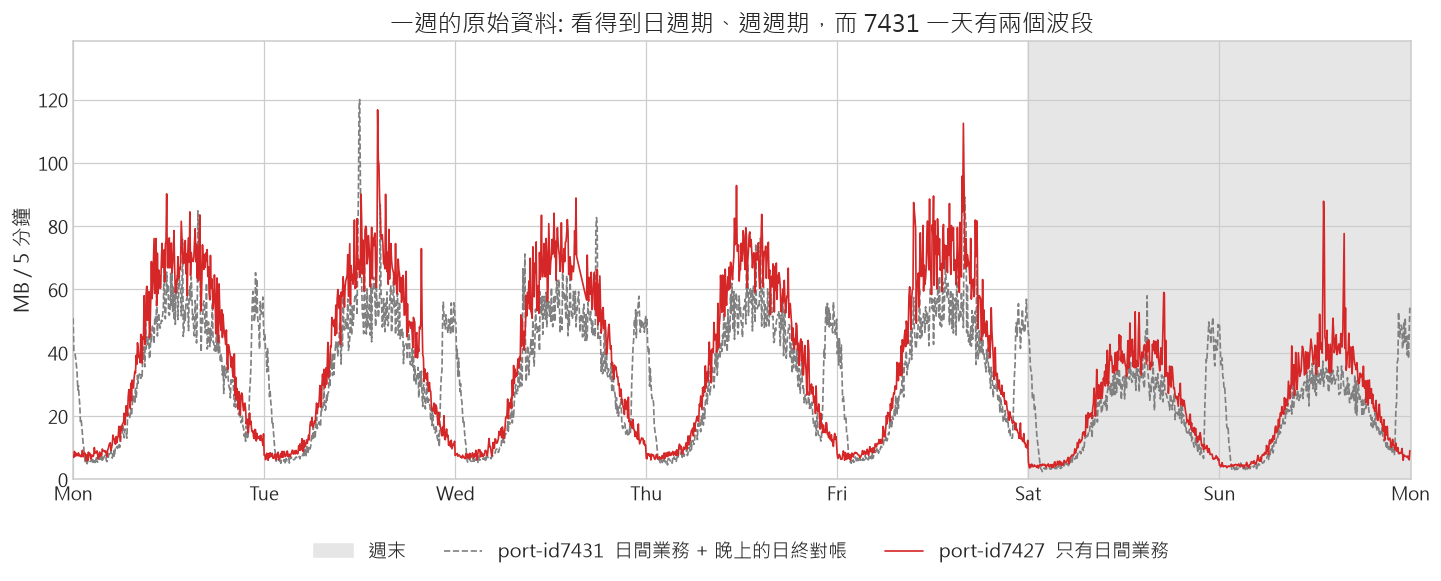

In [4]:
# 🎯 一整週的原始線，兩個 port 疊在一起: 日週期、週週期，以及一天之內有幾個波段。

# ============ ⚙️ 可調參數 ============
SECOND_PORT = "port-id7431"   # 圖上第二條對照線。選它是因為日間業務之外，晚上還有一段日終對帳
WEEK_INDEX = 1                # 要畫資料裡的第幾個完整週 (0 起算)。第 0 個週一前面不滿一天，
                              # 圖的左邊會缺一塊，所以預設從第 1 個週一起算
# ====================================

# ---- 1. 挑樣本與挑一個完整的週一到週日 ----
#         只留 event_label == "normal" 的格子: 注入的事件會把某幾個小時整片抬起來，
#         那不是這個 port 平常的樣子。
clean_all = features[features.event_label == "normal"].copy()
mondays = [t for t in pd.date_range(clean_all.timestamp.min().normalize(),
                                    clean_all.timestamp.max().normalize(), freq="D")
           if t.dayofweek == 0]
week0 = mondays[WEEK_INDEX]
week1 = week0 + pd.Timedelta(days=7)

# ---- 2. 畫圖。原始取樣點一格都不聚合 (5 分鐘一格，一週 2016 格) ----
#         聚合成小時平均會把晚上那段兩小時的對帳抹平，而那正是這張圖要看的東西。
fig, ax = plt.subplots(figsize=(13.2, 5.4), dpi=110)
for k in (5, 6):                                  # 週末底色: k=5 週六、k=6 週日
    a = week0 + pd.Timedelta(days=k)
    ax.axvspan(a, a + pd.Timedelta(days=1), color="0.90", zorder=0,
               label="週末" if k == 5 else None)
LINES = [(SECOND_PORT, "0.50", "--", "port-id7431  日間業務 + 晚上的日終對帳"),
         (PRIMARY_PORT, ACC, "-", "port-id7427  只有日間業務")]
for pid, color, ls, lab in LINES:
    w = clean_all[(clean_all.port_id == pid)
                  & (clean_all.timestamp >= week0) & (clean_all.timestamp < week1)]
    ax.plot(w.timestamp, w[TARGET] / 1e6, color=color, ls=ls, lw=1.1, label=lab, zorder=3)
ax.set_xlim(week0, week1)
ax.set_ylim(0, ax.get_ylim()[1] * 1.10)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a"))     # 刻度寫星期幾，不寫日期
ax.set_ylabel("MB / 5 分鐘", fontsize=13)
ax.tick_params(labelsize=11.5)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=3, fontsize=12.5,
          framealpha=0.95)
ax.set_title("一週的原始資料: 看得到日週期、週週期，而 7431 一天有兩個波段",
             fontsize=15.5)
plt.tight_layout(); show_fig(fig)


---

## 兩個模型怎麼分工
### 資料看完了，先把接下來要做的東西畫成一張圖，後面每一節都會按照說明其中一塊。

```mermaid
flowchart TB
    classDef hot fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff;

    RAW["30 天原始資料"] --> D1{"是 2/24 之前嗎"}
    D1 -->|"否"| HOLD["留作驗證<br/>兩個模型都不看"]
    D1 -->|"是"| TR["訓練資料"]
    TR -->|"扣掉夜間大量傳檔<br/>那幾個小時"| P["主模型 Prophet<br/>這個時刻的正常是多少"]
    P -->|"實際值減掉正常值<br/>大量傳檔整段留在這裡"| R["殘差"]
    R --> G["殘差模型 XGBoost<br/>不正常正在往哪裡走"]
    P --> SUM["未來流量推算值"]
    G --> SUM
    SUM --> D3{"越過容量門檻 T 嗎"}
    D3 -->|"是"| PAGE["預警系統送出通知"]
    D3 -->|"否"| QUIET["只記錄，不預警"]

    class P,G hot
```

#### 兩個模型各司其職: 主模型 prophet + 殘差模型 XGboost = 照現在這個走勢，未來的流量預測值為多少？

| | 主模型 (Prophet) | 殘差模型 (XGBoost) |
| --- | --- | --- |
| 回答什麼 | 這個時刻**正常**是多少 | **不正常**正在往哪裡走 |
| 訓練資料 | 訓練期扣掉夜間大量傳檔那幾個小時，只看平常的樣子 | 訓練期全部，**傳檔的爬坡刻意留著** |
| 輸出 | 季節基準，以及實際值減掉它剩下的殘差 | 未來 "指定" 分鐘的殘差水準與它的區間 |


理論課把這件事寫成一句話: **殘差不等於異常**。殘差只是扣掉可預期結構之後剩下的訊號，要拿它做提前預警，訓練資料裡就必須留著異常發生前的那一段:

> **為什麼程式裡寫的是 `HistGradientBoostingRegressor` 而不是 `xgboost`**: 兩者都是梯度提升樹，做的事情一樣，但前者是 scikit-learn 內建的，課程環境不必多裝一個套件。

<p align="center"><img src="slides/u07_residual_vs_anomaly.png" width="80%" alt="單元 07 的投影片: 左邊比較 Residual 異常偵測與 Residual 告警預測的輸入輸出與資料需求，右邊指出殘差不等於異常，要做預警就得讓模型看過異常前的殘差變化"></p>


---

## 主模型 Prophet: 學會這個時刻的正常是多少

```mermaid
flowchart LR
    N1["看資料<br/>做得了預警嗎<br/>平常什麼規律"] --> N2["主模型 Prophet<br/>這個時刻的正常是多少"] --> N3["殘差模型 XGBoost<br/>不正常往哪裡走<br/>合成預警規則"] --> N4["驗證<br/>這套規則能不能上場"]
    style N2 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

##### Prophet 把一條時間序列拆成四塊，分開配、再加回去:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

- $g(t)$ 趨勢，長期水準往哪走
- $s(t)$ 季節，這裡同時放 daily 與 weekly 兩組，也就是上一節量到的那兩個週期
- $h(t)$ 已知排程造成的偏移。只餵**事前公告過而且會重複發生**的視窗 (開盤微爆、收盤集合競價、日終對帳)，事後整理的事件目錄不進模型
- $\epsilon_t$ 剩下的，也就是**殘差**。做預警的那一節整節都靠它

<p align="center"><img src="slides/u07_prophet.png" width="80%" alt="單元 07 的 Prophet 投影片: 把時間序列拆解為趨勢、季節性、事件與殘差，再組合成最終預測，是一個可解釋的時間序列預測模型"></p>

---

## 先立一條及格線

任何模型要進正式環境，得先贏過一行程式就寫得完的做法。理論課那張圖已經把這幾種基礎方法排好了，下一格挑四種跑一遍，全部跟 Prophet 用同一個 holdout:

- **seasonal naive (weekly lag)**: 把訓練期最後一整週的數值，不做任何調整直接往前貼上當作預測值
- **moving average (1 day)**: 取最近一天的平均，當作預測值
- **exponential smoothing (Holt-Winters)**: 一個趨勢再加上一組日季節性
- **prophet (default)**: 每一個參數都用預設值

<p align="center"><img src="slides/u07_baselines.png" width="80%" alt="單元 07 的基礎預測方法投影片: Naive Forecast、Seasonal Naive、Moving Average、Exponential Smoothing 四種方法各自的假設、公式與適用情境，結論是複雜模型若不能穩定勝過 Naive 或 Seasonal Naive 就不一定值得部署"></p>


,MAE,RMSE,WAPE,MASE
method,,,,
moving average (1 day),19.686,23.400,0.698,4.682
exponential smoothing (Holt-Winters),9.846,13.509,0.349,2.342
seasonal naive (weekly lag),3.623,6.385,0.129,0.862
prophet (default),7.043,9.215,0.250,1.675



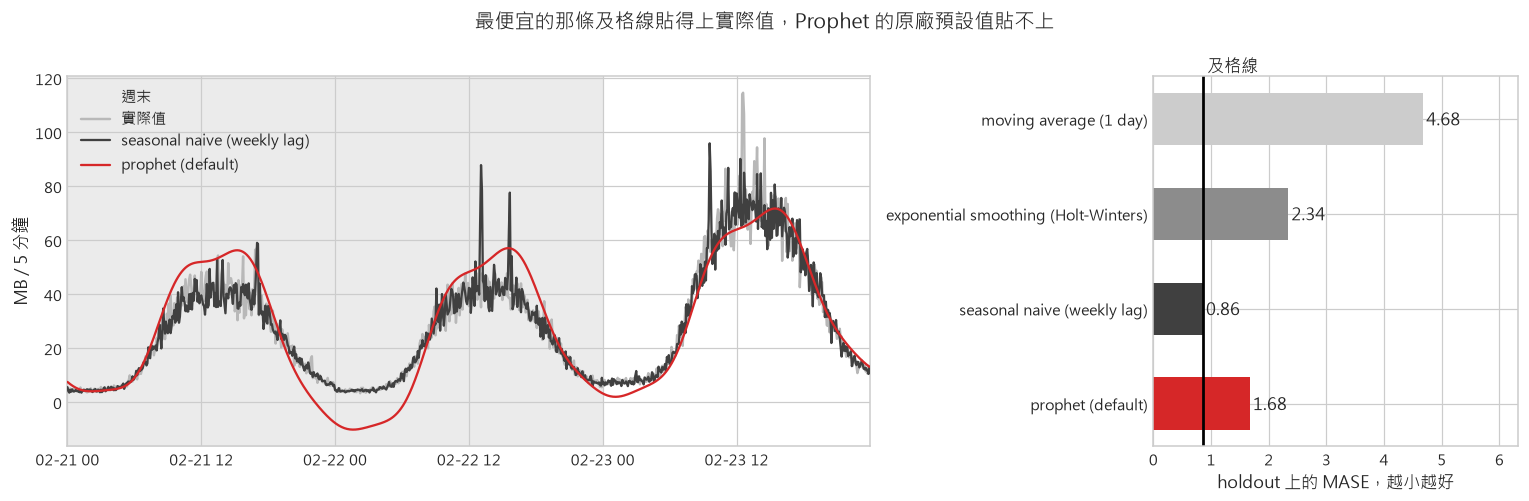

In [5]:
# 🎯 四種基礎方法與 Prophet 預設值，跑在同一個 holdout 上。
# 📦 statsmodels: Python 的統計模型套件，這一格只用它的 Holt-Winters 當對照組。
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ============ ⚙️ 可調參數 ============
MA_WINDOW = STEPS_PER_DAY     # moving average 取最近幾格的平均。一天 288 格。
                              # 調短: 水平線的高度貼近最後一小時; 調長: 接近長期平均，一樣錯
HW_PERIODS = STEPS_PER_DAY    # Holt-Winters 的季節週期有幾格。288 格就是一天。
                              # 改成一週 (2016): 形狀放得進去，但要估的季節參數多 7 倍
SN_LAG = 7 * STEPS_PER_DAY    # seasonal naive 複製多長的週期。7 天 = 2016 格
PROPHET_INTERVAL, PROPHET_SAMPLES = 0.95, 300   # 只影響區間，不影響點預測 yhat
# ====================================

# ---- 1. 切資料 ----
#         train 用來配模型，test 是 holdout (完全不給模型看)。
#         事件點不進精度評估: 事件是我們要抓的東西，不是模型該學會預測的東西。
series_raw = (port_hist.reset_index()[["timestamp", TARGET, "event_label"]]
              .rename(columns={"timestamp": "ds", TARGET: "y"}))
train = series_raw[series_raw.ds < ACC_TRAIN_END].reset_index(drop=True)
test = series_raw[(series_raw.ds >= ACC_TRAIN_END) & (series_raw.ds < ACC_TEST_END)].reset_index(drop=True)
CLEAN = (test.event_label == "normal").values      # 只在乾淨的格子上算誤差
y_tr, y_te = train["y"].values.astype(float), test["y"].values.astype(float)
H_STEPS = len(y_te)


# ---- 2. 講義列的準確度指標，之後每一種方法都套同一組 ----
#         MAE 容易解釋、RMSE 重罰大誤差、WAPE 用總量當分母。
#         MASE 的分母是「拿前一格當預測」在訓練期的平均誤差，所以 MASE < 1 才叫贏過 naive。
def mae(y, yh):  return float(np.mean(np.abs(y - yh)))
def rmse(y, yh): return float(np.sqrt(np.mean((y - yh) ** 2)))
def wape(y, yh): return float(np.sum(np.abs(y - yh)) / max(np.sum(np.abs(y)), 1e-9))


naive1_mae = float(np.mean(np.abs(np.diff(y_tr))))


def mase(f):
    return mae(y_te[CLEAN], np.asarray(f, float)[CLEAN]) / naive1_mae


def score(name, f):
    """一種方法的四個指標算成一列。MAE 與 RMSE 換成 MB，WAPE 與 MASE 本來就沒有單位。"""
    f = np.asarray(f, float)
    return {"method": name,
            "MAE": mae(y_te[CLEAN], f[CLEAN]) / 1e6, "RMSE": rmse(y_te[CLEAN], f[CLEAN]) / 1e6,
            "WAPE": wape(y_te[CLEAN], f[CLEAN]), "MASE": mase(f)}


# ---- 3. 四種方法各跑一次，預測值收進 preds ----
#         seasonal naive: 把訓練期最後一個完整週期複製著往前鋪，整個方法就一行。
#         moving average: 取最後 MA_WINDOW 格的平均，一路平推成一條水平線。
#         Holt-Winters: 一個水準再加上一組日季節性。
#         Prophet: 每一個參數都用預設值。
preds, rows = {}, []
preds["seasonal naive (weekly lag)"] = np.tile(y_tr[-SN_LAG:], H_STEPS // SN_LAG + 1)[:H_STEPS]
preds["moving average (1 day)"] = np.repeat(y_tr[-MA_WINDOW:].mean(), H_STEPS)
hw = ExponentialSmoothing(y_tr, trend=None, seasonal="add", seasonal_periods=HW_PERIODS,
                          initialization_method="estimated").fit()
preds["exponential smoothing (Holt-Winters)"] = np.asarray(hw.forecast(H_STEPS), float)
train_p = train[["ds", "y"]]        # Prophet 只吃 ds 與 y 兩欄
np.random.seed(0)                   # Prophet 的區間是抽樣算的，固定亂數才每次一樣
m_auto = Prophet(interval_width=PROPHET_INTERVAL, uncertainty_samples=PROPHET_SAMPLES).fit(train_p)
preds["prophet (default)"] = m_auto.predict(test[["ds"]])["yhat"].values

# 表的列順序: 由上往下，模型納入的週期越來越多。
ORDER0 = ["moving average (1 day)", "exponential smoothing (Holt-Winters)",
          "seasonal naive (weekly lag)", "prophet (default)"]
rows = [score(n, preds[n]) for n in ORDER0]
BASELINE = "seasonal naive (weekly lag)"     # 這一章的及格線: 一行程式、零參數
PASS_MARK = mase(preds[BASELINE])


# ---- 4. 比較圖。參數修好之後還要再用一次，所以寫成函式 ----
#         左: holdout 三天，只畫 show 點名的那幾條; 右: 每一種方法的 MASE 長條。
def compare_panel(items, title, show=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), dpi=110,
                             gridspec_kw={"width_ratios": [2.2, 1]})
    ax = axes[0]
    ax.fill_between(test.ds, 0, 1, where=(test.ds.dt.dayofweek >= 5),
                    transform=ax.get_xaxis_transform(), color="0.92", zorder=0,
                    label="週末")
    ax.plot(test.ds, y_te / 1e6, color="0.72", lw=1.6, label="實際值", zorder=2)
    for nm, color, ls in items:
        if show is not None and nm not in show:
            continue
        ax.plot(test.ds, preds[nm] / 1e6, color=color, ls=ls, lw=1.5, label=nm, zorder=3)
    ax.set_xlim(test.ds.min(), test.ds.max())
    ax.set_ylabel("MB / 5 分鐘", fontsize=11); ax.legend(fontsize=9.5, loc="upper left")
    ax.tick_params(labelsize=10)

    ax = axes[1]
    ys = np.arange(len(items))[::-1]        # 倒過來，第一個項目才畫在最上面
    ax.barh(ys, [mase(preds[nm]) for nm, _, _ in items],
            color=[c for _, c, _ in items], height=0.55)
    for y, (nm, _, _) in zip(ys, items):
        ax.text(mase(preds[nm]) + 0.05, y, f"{mase(preds[nm]):.2f}", va="center", fontsize=11)
    ax.axvline(PASS_MARK, color="black", lw=1.8)
    ax.text(PASS_MARK, len(items) - 0.35, " 及格線", fontsize=11, va="top")
    ax.set_yticks(ys); ax.set_yticklabels([nm for nm, _, _ in items], fontsize=9.5)
    ax.set_xlim(0, max(mase(preds[nm]) for nm, _, _ in items) * 1.35)
    ax.set_xlabel("holdout 上的 MASE，越小越好", fontsize=11)
    ax.tick_params(labelsize=10)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(); show_fig(fig)


# ---- 5. 四種方法的成績表，再畫一次比較圖 ----
#         左圖只畫兩條: 最便宜的那條及格線，以及 Prophet 的原廠預設值，其餘兩條只進右邊的長條。
display(pd.DataFrame(rows).set_index("method").round(3))
compare_panel([("moving average (1 day)", "0.80", "-"),
               ("exponential smoothing (Holt-Winters)", "0.55", "-."),
               (BASELINE, "0.25", "-"),
               ("prophet (default)", "tab:red", "-")],
              "最便宜的那條及格線貼得上實際值，Prophet 的原廠預設值貼不上",
              show=[BASELINE, "prophet (default)"])


#### **先不要換模型。** 
因為當你直接跑預測模型時，prophet 會自動根據時間抓取日週期、週週期、年週期，但是 `weekly_seasonality='auto'` 只決定**要不要放**這一組季節性，放進去之後階數是寫死的 **3**，daily 是 4。它從來沒有看過你的資料需要幾階。所以先問的是: 是 Prophet 不適合這份資料，還是還沒調到對的那一個參數。

---

## 沒跨過及格線，先把殘差攤開來看

- 殘差只是雜訊 -> 那是模型能力的極限，換模型才有用
- 殘差裡還留著看得出來的**結構** -> 那是模型漏了某個成分，而那個成分補得回來

怎麼攤: 把一週切成 168 個 (星期， 小時) 槽，同一個槽的殘差取平均。用 168 槽而不是 7 天，是因為一天之內殘差會變號，只看 7 天的平均會互相抵消。



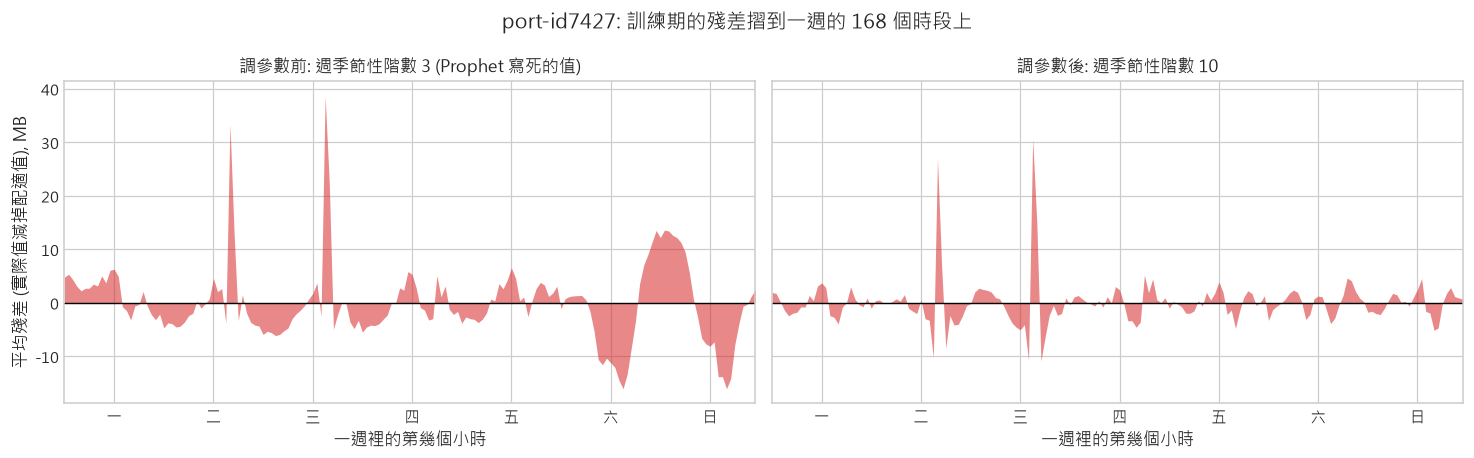

In [6]:
# 🎯 殘差沿一週摺疊，看模型漏了什麼，再把診斷指出來的那個參數用交叉驗證挑一次。
from prophet.diagnostics import cross_validation, performance_metrics

# ============ ⚙️ 可調參數 ============
DEFAULT_FO = 3        # Prophet 內建 weekly 季節性寫死的階數，拿它當對照組
DAILY_FO = 4          # daily 那一組的階數，跟 Prophet 內建相同。這一節只動 weekly，變因才只有一個
FO_GRID = [3, 6, 10, 14, 20, 30, 45]   # 要試哪幾個 weekly 階數。網格要涵蓋「明顯太小」到
                                       # 「明顯太大」，挑出來的值才不會落在邊界上
CV_INITIAL, CV_PERIOD, CV_HORIZON = "12 days", "2 days", "1 days"
# 交叉驗證 (rolling origin): 先用前 12 天訓練，每次往前推 2 天，每次預測未來 1 天。
# initial 調大: 每個 fold 看到的歷史變多但 fold 數變少; horizon 調大: 量到的是更遠的預測有多準。
# ====================================


# ---- 1. 配 Prophet 的設定集中在這個函式，這一章之後每一次配模型都呼叫它 ----
#         weekly_fourier_order 是這一節唯一要調的參數: 用幾組正弦餘弦去描述「一週」的形狀。
#         調小 (3): 描不出週末那段接近方波的轉折; 調大 (20 到 45): 訓練誤差還會往下，
#         但交叉驗證誤差開始回升，也就是過擬合。
#         另外三個 (changepoint_prior_scale / seasonality_prior_scale / changepoint_range)
#         全部留在 Prophet 的預設值: 同時動兩個參數就分不出誤差的變化是哪一個帶來的。
def fit_prophet(train_df, weekly_fourier_order=10, changepoint_prior_scale=0.05,
                seasonality_prior_scale=10.0, interval_width=0.95, uncertainty_samples=300,
                changepoint_range=0.8):
    """daily 與 weekly 兩組季節性明確指定階數，(ds, y) 以外的欄位一律當成 h(t) 的迴歸項。"""
    if not HAS_PROPHET:
        raise RuntimeError("這一章從這裡開始需要 Prophet，請先跑 1_pkg_checker.ipynb 把環境補齊")
    # 三個 *_seasonality=False 是關掉 Prophet 自動加的那一組，改成自己用 add_seasonality 指定階數。
    m = Prophet(growth="linear", daily_seasonality=False, weekly_seasonality=False,
                yearly_seasonality=False, seasonality_mode="additive",
                interval_width=interval_width,
                changepoint_prior_scale=changepoint_prior_scale,
                changepoint_range=changepoint_range,
                seasonality_prior_scale=seasonality_prior_scale,
                uncertainty_samples=uncertainty_samples)
    m.add_seasonality("daily",  period=1, fourier_order=DAILY_FO)
    m.add_seasonality("weekly", period=7, fourier_order=weekly_fourier_order)
    for c in train_df.columns:            # (ds, y) 以外而且有兩種以上的值的欄位就是 h(t)
        if c not in ("ds", "y") and train_df[c].nunique() > 1:
            m.add_regressor(c)
    m.fit(train_df)
    return m


def predict_full(m, frame):
    """預測時要餵回模型當初宣告過的每一個迴歸項，欄位不齊 Prophet 會直接報錯。"""
    return m.predict(frame[["ds"] + list(m.extra_regressors)])


def predict_with(m, frame):
    """同樣是預測，但只留下畫圖與算殘差會用到的四欄。"""
    return predict_full(m, frame)[["ds", "yhat", "yhat_lower", "yhat_upper"]]


# ---- 2. 殘差摺疊: 把一週切成 168 個 (星期, 小時) 槽，同一個槽的殘差取平均 ----
#         摺完是平的，代表模型已經把週期結構吸收完了; 摺完還看得出形狀，代表漏了成分。
def fold_residual(frame):
    slot = pd.to_datetime(frame["ds"]).dt.dayofweek * 24 + pd.to_datetime(frame["ds"]).dt.hour
    r = pd.DataFrame({"slot": slot, "resid": frame["y"] - frame["yhat"]})
    return r.groupby("slot")["resid"].mean().reindex(range(168), fill_value=0.0)


# ---- 3. 兩個階數各配一個模型，把它們的殘差摺疊起來畫成兩張 ----
#         左邊是 Prophet 寫死的階數，右邊是等一下要挑出來的那一個，只差這一個參數。
folds, fits = {}, {}
for fo in (DEFAULT_FO, 10):
    np.random.seed(0)
    fits[fo] = fit_prophet(train_p, weekly_fourier_order=fo)
    folds[fo] = fold_residual(train_p.merge(predict_with(fits[fo], train_p), on="ds"))

DAY_TICKS = ["一", "二", "三", "四", "五", "六", "日"]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2), dpi=110, sharey=True)
for ax, fo, name in zip(axes, (DEFAULT_FO, 10),
                        [f"調參數前: 週季節性階數 {DEFAULT_FO} (Prophet 寫死的值)",
                          "調參數後: 週季節性階數 10"]):
    ax.fill_between(range(168), 0, folds[fo].values / 1e6, color=ACC, alpha=0.55, lw=0)
    ax.axhline(0, color="black", lw=0.9)          # 零線: 上方代表模型低估，下方代表高估
    ax.set_xticks(range(12, 168, 24))             # 刻度放在每一天的正中間
    ax.set_xticklabels(DAY_TICKS, fontsize=10)
    ax.set_xlim(0, 167)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("一週裡的第幾個小時", fontsize=11)
    ax.tick_params(labelsize=10)
axes[0].set_ylabel("平均殘差 (實際值減掉配適值), MB", fontsize=11)
fig.suptitle(f"{PRIMARY_PORT}: 訓練期的殘差摺到一週的 168 個時段上", fontsize=13)
plt.tight_layout(); show_fig(fig)


# ---- 4. 只掃一個軸 (weekly 階數)，其餘參數留在預設值 ----
#         每個階數配一次模型，然後量兩件事: 訓練誤差 (參數越多一定越小，沒有最低點)，
#         以及交叉驗證誤差 (換一段沒看過的資料還準不準，選模型看這一條)。
#         順手把 holdout 上的點預測存進 preds，下一格比較圖要用。
def scan_one(fo):
    np.random.seed(0)
    m = fit_prophet(train_p, weekly_fourier_order=fo, uncertainty_samples=0)
    tr = rmse(train_p.y.values, m.predict(train_p[["ds"]])["yhat"].values)
    cv = cross_validation(m, initial=CV_INITIAL, period=CV_PERIOD, horizon=CV_HORIZON,
                          disable_tqdm=True)
    cv_r = float(performance_metrics(cv, rolling_window=1)["rmse"].iloc[0])
    preds[f"Prophet (weekly fo={fo})"] = m.predict(test[["ds"]])["yhat"].values
    return {"weekly_fourier_order": fo, "季節項參數個數": 2 * fo,
            "自己看過的資料誤差 (MB)": round(tr / 1e6, 2),
            "沒看過的資料誤差 (MB)": round(cv_r / 1e6, 2)}


fo_tbl = pd.DataFrame([scan_one(fo) for fo in FO_GRID]).set_index("weekly_fourier_order")
BEST_FO = int(fo_tbl["沒看過的資料誤差 (MB)"].idxmin())      # 選模型只看這一欄


---

## 把挑出來的階數放回同一張圖驗一次


,MAE,RMSE,WAPE,MASE
method,,,,
Prophet (weekly fo=10),3.249,5.211,0.115,0.773
seasonal naive (weekly lag),3.623,6.385,0.129,0.862
prophet (default),7.043,9.215,0.250,1.675
exponential smoothing (Holt-Winters),9.846,13.509,0.349,2.342
moving average (1 day),19.686,23.400,0.698,4.682



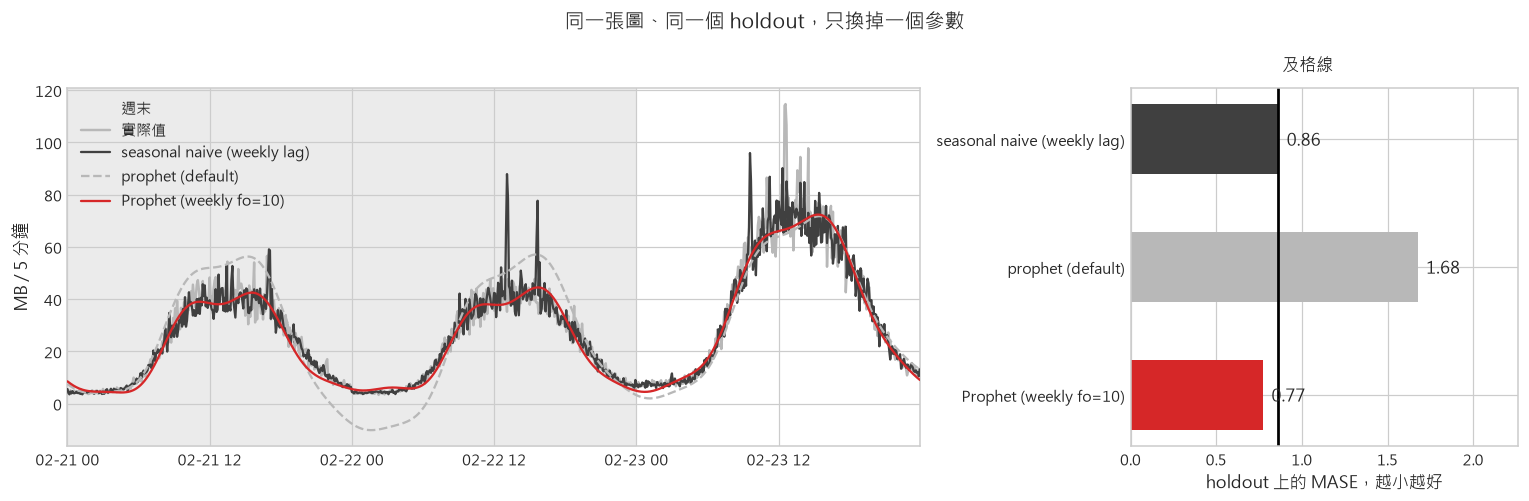

In [7]:
# 🎯 同一個函式、同一個 holdout，只換成交叉驗證挑出來的那一組設定。
#    預測值不用重算: 上一格掃 fo 的時候已經把 holdout 的點預測存進 preds 了。
rows.append(score(f"Prophet (weekly fo={BEST_FO})", preds[f"Prophet (weekly fo={BEST_FO})"]))
display(pd.DataFrame(rows).set_index("method").sort_values("MASE").round(3))
# 三條線: 及格線、Prophet 預設值、只把 weekly 階數換成 BEST_FO 的 Prophet。
# 後兩條之間只差這一個參數，圖上兩條線的落差就是這一個參數造成的。
compare_panel([(BASELINE, "0.25", "-"),
               ("prophet (default)", "0.72", "--"),
               (f"Prophet (weekly fo={BEST_FO})", "tab:red", "-")],
              "同一張圖、同一個 holdout，只換掉一個參數")


---

## Fourier Order 這個階數就是: 這條曲線最多可以有幾個轉折

- 一個 port 的流量在每天都有上下，且一週中最大流量有時高有時低
- 要用**一條平滑的曲線**描述它一週，而且只准這條曲線有三個轉折的話，畫出來就會不貼合
- **所以階數不是越高代表模型越強,是「這條季節曲線允許有多少轉折」
- ** Prophet 的 `weekly_seasonality=True` 只決定要不要放這一組季節性，放進去之後參數是寫死的 3,它從來沒有看過你的資料需要幾階。所以要記得自己看殘差做調整

10 比 3 好，那 20 會不會更好？45 呢？下一格畫兩張圖回答這兩件事: **左邊那張看季節曲線的形狀被改成什麼樣，右邊那張看階數該停在哪裡。**


,季節項參數個數,自己看過的資料誤差 (MB),沒看過的資料誤差 (MB),選它
weekly_fourier_order,,,,
3,6,13.16,10.14,
6,12,12.32,9.53,
10,20,11.90,8.65,<-- 沒看過的資料誤差最低
14,28,11.85,9.06,
20,40,11.71,9.47,
30,60,11.52,10.22,
45,90,11.23,11.27,



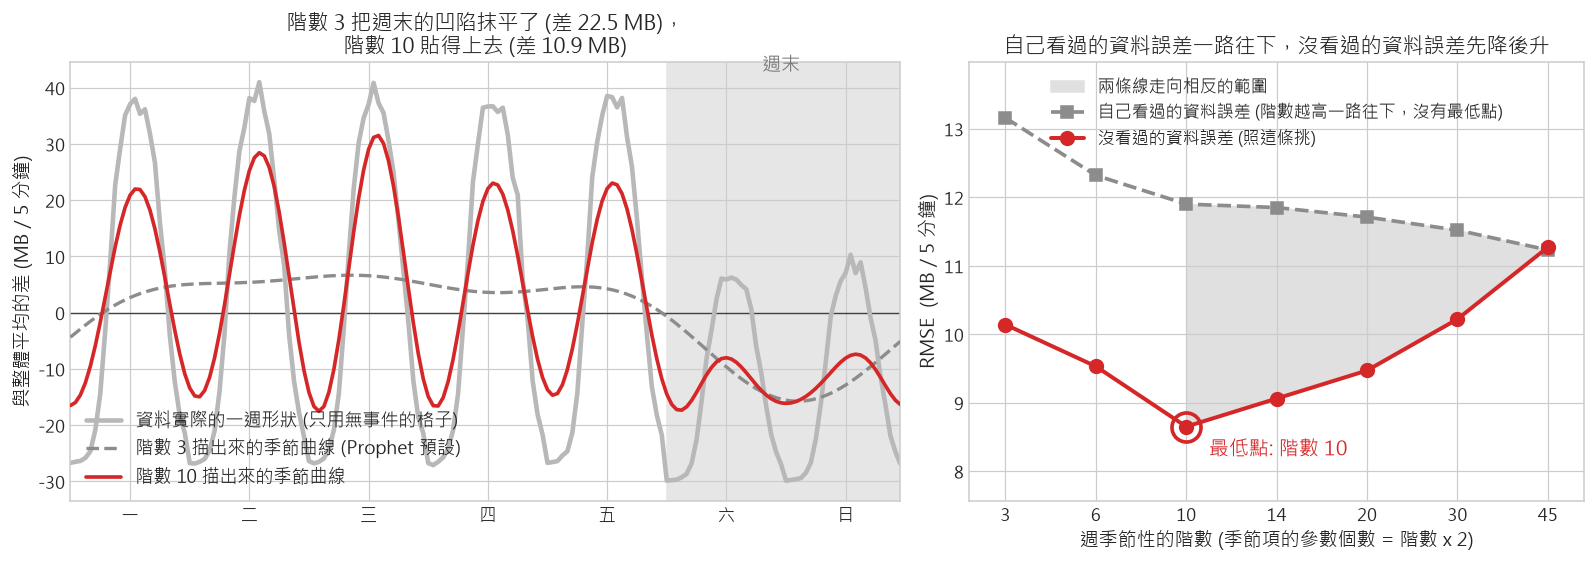

In [8]:
# 🎯 一張表加兩張圖: 表看每個階數的兩種誤差，左圖看階數改了季節曲線的什麼，
#    右圖看階數該停在哪裡。

# ---- 1. 先看表: 上一格掃出來的每一個階數，各自的兩種誤差 ----
#         「自己看過的資料誤差」一路往下，所以它沒有最低點; 「沒看過的資料誤差」先降後升，
#         挑階數只看後面這一欄。
fo_show = fo_tbl.copy()
fo_show["選它"] = ["<-- 沒看過的資料誤差最低" if fo == BEST_FO else "" for fo in fo_show.index]
display(fo_show)

# ---- 2. 資料實際的一週形狀，當成兩條季節曲線的比對對象 ----
#         把訓練期每一格按 (星期幾, 幾點) 分組取平均得到 168 個槽，再減掉整體平均:
#         季節項 s(t) 本來就是以 0 為中心的偏移量，不減的話兩條線會差一整個水準。
#         只留無事件的格子: 注入的事件不是這個 port 每一週都會重複的形狀。
train_clean = train[train.event_label == "normal"]
train_slot = train_clean.assign(slot=train_clean.ds.dt.dayofweek * 24 + train_clean.ds.dt.hour)
weekly_actual = train_slot.groupby("slot")["y"].mean().reindex(range(168))
weekly_actual = (weekly_actual - train_clean.y.mean()) / 1e6

if BEST_FO not in fits:              # 換資料時 BEST_FO 有可能不是 10，當場補配一個
    np.random.seed(0)
    fits[BEST_FO] = fit_prophet(train_p, weekly_fourier_order=BEST_FO)


def weekly_shape(fo):
    """這個階數的模型，週季節項沿 168 個槽的樣子 (MB)，跟 weekly_actual 在同一條軸上。"""
    pr = fits[fo].predict(train_p[["ds"]])
    pr["slot"] = pr.ds.dt.dayofweek * 24 + pr.ds.dt.hour
    return pr.groupby("slot")["weekly"].mean().reindex(range(168)) / 1e6


# ---- 3. 左圖: 資料實際的一週形狀，配上兩個階數各自描出來的季節曲線 ----
fig, axes = plt.subplots(1, 2, figsize=(14.6, 5.2), dpi=110,
                         gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
ax.axhline(0, color=INK, lw=0.9, zorder=1)
ax.axvspan(120, 167, color="0.90", zorder=0)          # 第 120 槽 (週六 0 點) 之後是週末
ax.text(143, float(weekly_actual.max()) * 1.05, "週末", ha="center", fontsize=12.5,
        color="0.45")
ax.plot(range(168), weekly_actual.values, color="0.72", lw=3.0, zorder=2,
        label="資料實際的一週形狀 (只用無事件的格子)")
ax.plot(range(168), weekly_shape(DEFAULT_FO).values, color=GREY, ls="--", lw=2.2, zorder=3,
        label=f"階數 {DEFAULT_FO} 描出來的季節曲線 (Prophet 預設)")
ax.plot(range(168), weekly_shape(BEST_FO).values, color=ACC, lw=2.4, zorder=4,
        label=f"階數 {BEST_FO} 描出來的季節曲線")
ax.set_xticks(range(12, 168, 24)); ax.set_xticklabels(DAY_TICKS, fontsize=11.5)
ax.set_xlim(0, 167)
ax.set_ylabel("與整體平均的差 (MB / 5 分鐘)", fontsize=12.5)
ax.tick_params(labelsize=11)
ax.legend(loc="lower left", fontsize=11.5, framealpha=0.95)
# 兩條曲線各自跟實際形狀差多少 (168 個槽的 RMSE)，算出來寫進標題。
err3 = float(np.sqrt(np.nanmean((weekly_shape(DEFAULT_FO).values - weekly_actual.values) ** 2)))
errB = float(np.sqrt(np.nanmean((weekly_shape(BEST_FO).values - weekly_actual.values) ** 2)))
ax.set_title(f"階數 {DEFAULT_FO} 把週末的凹陷抹平了 (差 {err3:.1f} MB)，\n"
             f"階數 {BEST_FO} 貼得上去 (差 {errB:.1f} MB)", fontsize=14)

# ---- 4. 右圖: 兩種誤差沿階數的走勢。灰底標出兩條線走向相反的那一段 ----
ax = axes[1]
tr_v = fo_tbl["自己看過的資料誤差 (MB)"].values
cv_v = fo_tbl["沒看過的資料誤差 (MB)"].values
xg = np.arange(len(fo_tbl))                       # 橫軸用等距的序號，階數本身不是等距的
b_cv = int(np.argmin(cv_v))
ax.fill_between(xg, tr_v, cv_v, where=(xg >= b_cv), color="0.88", zorder=0,
                label="兩條線走向相反的範圍")
ax.plot(xg, tr_v, color=GREY, lw=2.4, ls="--", marker="s", ms=8, zorder=4,
        label="自己看過的資料誤差 (階數越高一路往下，沒有最低點)")
ax.plot(xg, cv_v, color=ACC, lw=2.6, marker="o", ms=9, zorder=5,
        label="沒看過的資料誤差 (照這條挑)")
ax.plot([b_cv], [cv_v[b_cv]], marker="o", ms=19, mfc="none", mec=ACC, mew=2.4, zorder=6)
ax.text(b_cv + 0.25, cv_v[b_cv] - (cv_v.max() - cv_v.min()) * 0.16,
        f"最低點: 階數 {fo_tbl.index[b_cv]}", fontsize=13, color=ACC, ha="left")
ax.set_xticks(xg)
ax.set_xticklabels([str(fo) for fo in fo_tbl.index], fontsize=12)
ax.set_xlabel("週季節性的階數 (季節項的參數個數 = 階數 x 2)", fontsize=12.5)
ax.set_ylabel("RMSE  (MB / 5 分鐘)", fontsize=12.5)
ax.set_xlim(-0.4, xg[-1] + 0.4)
lo, hi = min(tr_v.min(), cv_v.min()), max(tr_v.max(), cv_v.max())
ax.set_ylim(lo - (hi - lo) * 0.24, hi + (hi - lo) * 0.18)     # 上下留白給文字與圖例
ax.tick_params(labelsize=11)
ax.legend(loc="upper center", fontsize=11, framealpha=0.96)
ax.set_title("自己看過的資料誤差一路往下，沒看過的資料誤差先降後升", fontsize=14)
plt.tight_layout(); show_fig(fig)


---

## 理論課那張交叉驗證就是在講右圖這個黃金交叉:

<p align="center"><img src="slides/u07_cross_validation.png" width="80%" alt="單元 07 的交叉驗證投影片: 把資料切成多個 fold，每一個 fold 都用前面那段訓練、預測後面沒看過的一段，用來確認模型對沒看過的資料是不是也預測得好"></p>

### 總結: 如何挑階數
- **選模型看交叉驗證，訓練誤差只能拿來確認模型配得起來。** 兩條線一旦開始走反向，繼續往右走換到的只是訓練誤差變小，真實表現反而變差。
- **不要背那個階數。** 這份資料的週末平均是平日的六成、兩段之間的轉折又陡，才需要這麼高的階數。


---

## 成功訓練主模型 prophet

Prophet 把 $\hat{y}$ 拆成三條，三條加起來就是預測值，所以預測值不準的時候看得出來是哪一塊壞掉，前面診斷週季節性靠的就是這種可拆解性:

- **trend $g(t)$ 在 30 天裡只動了幾 MB**,而底下 daily 那一塊一天之內就擺動幾十 MB
- **weekly $s(t)$ 是五個高峰配兩個矮丘**
- **daily $s(t)$** 一天之內的擺動就超過 trend 三十天的總幅度六倍，所以原始曲線上看不見趨勢



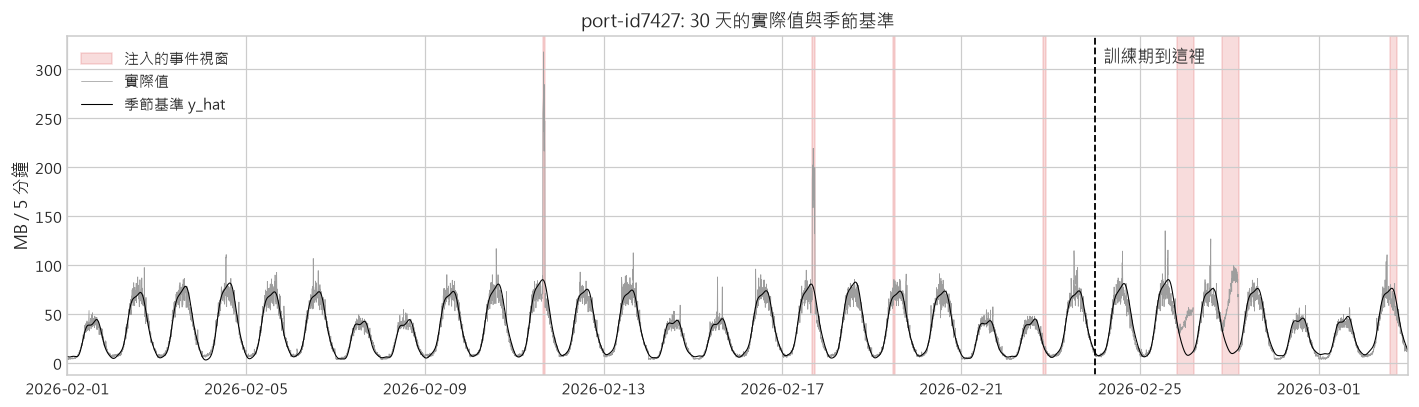


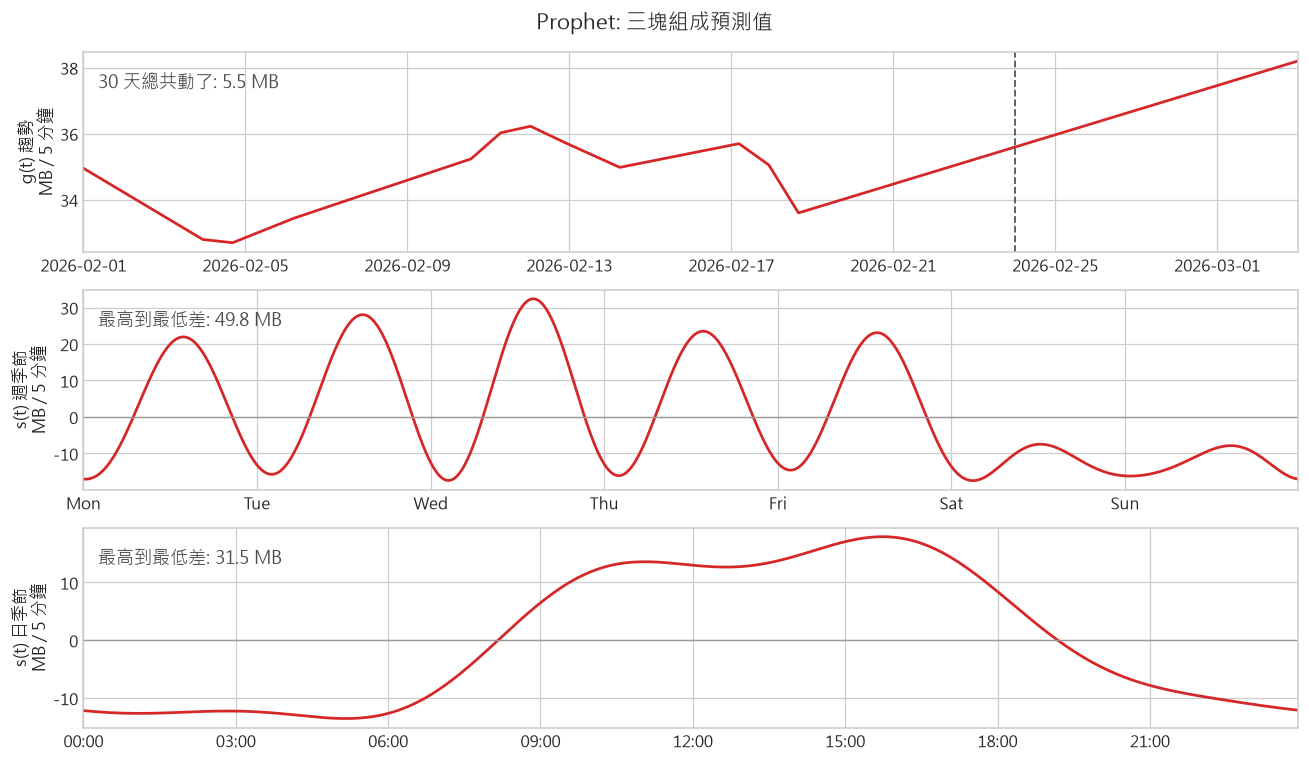

In [9]:
# 🎯 用挑好的設定把五個 port 各配一個模型，之後每一段都用它們。

# ============ ⚙️ 可調參數 ============
H_MIN = 135     # horizon: 預警要提前多久 (分鐘)。一格 5 分鐘，135 分鐘 = 往前推 27 格。
                # 調小: 推得近、誤差小，但留給維運的處置時間跟著變短;
                # 調大: 處置時間更長，但爬坡短於 h + N_CONSEC x 5 分鐘的事故一定抓不到
N_CONSEC = 4      # 要連續幾格都指向越線才算一次預警。4 格 = 連續 20 分鐘。
                # 調小: 早幾分鐘預警，但單格越線在這份資料上是日常，誤警會變多;
                # 調大: 要多等幾分鐘才確定，提前量就少那幾分鐘
# 這兩個怎麼挑，見殘差模型之後「兩個設定值一起挑」那一節。
BULK_TRANSFER_KINDS = {"partner_file_exchange", "desktop_backup"}
# 哪幾種已公告的排程不當 h(t) 的輸入，而且要把它們的時段從 Prophet 的訓練集裡拿掉。
# 理由: 這一章要的基準線是「沒有人在傳檔的話流量會是多少」。基準線一旦學會了它們，
# 殘差就只剩「這一次傳的比平常多多少」，而預警要讀的是整段傳檔把流量推到多高。
# 改成空集合: 注入高度只有 0.51 到 0.71 會留在殘差裡，其餘被基準線吸收掉。
# ====================================
H_STEP = H_MIN // 5                                                       # 27 格
SCHED_KINDS = sorted(set(schedule.kind.unique()) - BULK_TRANSFER_KINDS)   # 剩下的就是 h(t)
ALL_PORT_IDS = sorted(features.port_id.unique())


# ---- 1. 一個 port 餵給 Prophet 的輸入表: ds、y，再加上每一種排程各一欄 0/1 旗標 ----
def build_frame(pid):
    s = (features[features.port_id == pid][["timestamp", TARGET]]
         .rename(columns={"timestamp": "ds", TARGET: "y"})
         .dropna().sort_values("ds").reset_index(drop=True))
    rows_s = schedule[schedule.port_id == pid]
    for kind in SCHED_KINDS:              # 一種排程一欄: 落在該種排程任何一段視窗內就填 1.0
        flag = pd.Series(0.0, index=s.index)
        for _, r in rows_s[rows_s.kind == kind].iterrows():
            flag[(s["ds"] >= r.start_time) & (s["ds"] <= r.end_time)] = 1.0
        s[kind] = flag.values
    return s


PORT_FRAMES = {pid: build_frame(pid) for pid in ALL_PORT_IDS}


# ---- 2. 一個 port 配一個 Prophet，再算出整整 30 天的殘差 ----
#         兩個函式都做快取: Prophet 配一次要幾秒，而整章會取用很多次。
_MODELS, _FCACHE = {}, {}


def port_model(pid):
    """每個 port 配一次，只用 TRAIN_END 之前、而且不在大量傳檔視窗裡的資料。

    扣掉的範圍從視窗開始前 H_MIN 分鐘算起，所以傳檔前一個預警窗長度的資料也不進訓練集。"""
    if pid not in _MODELS:
        s = PORT_FRAMES[pid]
        keep = (s.ds < TRAIN_END).values.copy()
        for _, r_ in schedule[(schedule.port_id == pid)
                              & schedule.kind.isin(BULK_TRANSFER_KINDS)].iterrows():
            keep &= ~((s.ds >= r_.start_time - pd.Timedelta(minutes=H_MIN))
                      & (s.ds <= r_.end_time)).values
        np.random.seed(0)
        _MODELS[pid] = fit_prophet(s[keep], weekly_fourier_order=BEST_FO)
    return _MODELS[pid]


def port_forecast(pid):
    """整整 30 天的 y、yhat、95% 區間與殘差。TRAIN_END 之後的部分模型沒有看過。

    residual = y - yhat 就是「這一格比季節基準多了或少了多少」，這一欄是後面殘差模型、
    告警規則與驗證每一節共同的輸入。"""
    if pid not in _FCACHE:
        s = PORT_FRAMES[pid]
        g = s.merge(predict_with(port_model(pid), s), on="ds")
        g["residual"] = g["y"] - g["yhat"]
        _FCACHE[pid] = g
    return _FCACHE[pid]


fc = port_forecast(PRIMARY_PORT)

# ---- 3. 第一張圖: 30 天的實際值配上季節基準，紅色網底是注入的事件 ----
#         橫軸是 30 天、每 5 分鐘一格，所以圖拉寬、線畫細，不然整條會糊成一片。
fig, ax = plt.subplots(figsize=(13, 3.8), dpi=110)
_first_band = True
for _, ev_ in event_catalog.iterrows():
    if ev_["port_id"] in (PRIMARY_PORT, "MULTI"):
        ax.axvspan(ev_["start_time"], ev_["end_time"], alpha=0.16, color="tab:red", zorder=0,
                   label="注入的事件視窗" if _first_band else None)
        _first_band = False
ax.plot(fc.ds, fc.y / 1e6, color="0.62", lw=0.5, label="實際值")
ax.plot(fc.ds, fc.yhat / 1e6, color="black", lw=0.7, label="季節基準 y_hat")
ax.axvline(TRAIN_END, color="black", lw=1.2, ls="--")
ax.set_xlim(fc.ds.min(), fc.ds.max())
ax.text(TRAIN_END, ax.get_ylim()[1] * 0.92, "  訓練期到這裡", fontsize=11)
ax.set_ylabel("MB / 5 分鐘", fontsize=11); ax.legend(fontsize=10, loc="upper left")
ax.tick_params(labelsize=10)
ax.set_title(f"{PRIMARY_PORT}: 30 天的實際值與季節基準", fontsize=12)
plt.tight_layout(); show_fig(fig)

# ---- 4. 第二張圖: 把 y_hat 拆成三塊，三塊加起來就是預測值 ----
#         週季節每週重複，所以只畫一週; 日季節只畫一天。起點取資料裡的第一個星期一。
m_pri = port_model(PRIMARY_PORT)
full = predict_full(m_pri, PORT_FRAMES[PRIMARY_PORT])
mon = next(t for t in pd.date_range(full.ds.min().normalize(), full.ds.max().normalize(),
                                    freq="D") if t.dayofweek == 0)
wk_ = full[(full.ds >= mon) & (full.ds < mon + pd.Timedelta(days=7))]
dy_ = full[(full.ds >= mon + pd.Timedelta(days=1)) & (full.ds < mon + pd.Timedelta(days=2))]

fig, axes = plt.subplots(3, 1, figsize=(12, 7.0), dpi=110)
ax = axes[0]
ax.plot(full.ds, full.trend / 1e6, color="tab:red", lw=1.8)
ax.axvline(TRAIN_END, color="0.35", lw=1.2, ls="--")
ax.set_xlim(full.ds.min(), full.ds.max())
ax.set_ylabel("g(t) 趨勢\nMB / 5 分鐘", fontsize=11)

ax = axes[1]
ax.plot(wk_.ds, wk_.weekly / 1e6, color="tab:red", lw=1.8)
ax.axhline(0, color="0.6", lw=0.9)
ax.set_xlim(wk_.ds.min(), wk_.ds.max())
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a"))
ax.set_ylabel("s(t) 週季節\nMB / 5 分鐘", fontsize=11)

ax = axes[2]
ax.plot(dy_.ds, dy_.daily / 1e6, color="tab:red", lw=1.8)
ax.axhline(0, color="0.6", lw=0.9)
ax.set_xlim(dy_.ds.min(), dy_.ds.max())
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_ylabel("s(t) 日季節\nMB / 5 分鐘", fontsize=11)

# 三張子圖各算一次振幅寫在左上角。transAxes 讓座標讀的是子圖自己的 0 到 1 比例。
for a, amp, lab in ((axes[0], full.trend.max() - full.trend.min(), "30 天總共動了"),
                    (axes[1], wk_.weekly.max() - wk_.weekly.min(), "最高到最低差"),
                    (axes[2], dy_.daily.max() - dy_.daily.min(), "最高到最低差")):
    a.tick_params(labelsize=10.5)
    a.text(0.012, 0.90, f"{lab}: {amp / 1e6:.1f} MB", transform=a.transAxes,
           fontsize=12, color="0.30", va="top")
fig.suptitle("Prophet: 三塊組成預測值", fontsize=13.5)
plt.tight_layout(); show_fig(fig)


---

## 殘差模型 XGBoost: 學會不正常正在往哪裡走

```mermaid
flowchart LR
    N1["看資料<br/>做得了預警嗎<br/>平常什麼規律"] --> N2["主模型 Prophet<br/>這個時刻的正常是多少"] --> N3["殘差模型 XGBoost<br/>不正常往哪裡走<br/>合成預警規則"] --> N4["驗證<br/>這套規則能不能上場"]
    style N3 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

##### 主模型學會了「這個時刻的正常是多少」。預警要問的是另一件事。

- **Prophet 的預測只看時間戳。** 給它一個時刻，它回答那個時刻平常是多少它不讀最近幾格的觀測值，所以今晚有容量異常緩緩的爬升，它一點都不會反應。**今晚實際發生的事情，全部只留在殘差裡。**
- 殘差就是實際值減掉季節基準，也就是「這個時刻比平常多了或少了多少」。所以這一節要做的事只有一句: **殘差現在正在爬升，再過 "指定" (135) 分鐘它會爬升到多高。** 
- 把那個高度加回未來的季節基準，就是未來流量推算值。推算值碰到容量門檻 $T$ 就發出預警。

## 五個 port 的資料混在一起訓練，因為問的是同一個異常事件

這一章的目標是: **目前離自己的容量上限還有多遠。** 這句話跟 port 有多大無關。`port-id7427` 的容量是 82 MB、`port-id7428` 只有 25 MB,可是「已經用掉八成，而且還在往上」在兩個 port 上是同一件事。所以只要先把每個 port 的數字換算成「佔自己容量的幾成」,**一個 port 上發生過的爬坡就可以當成另一個 port 的訓練樣本**。

**但只有同一種性質的異常可以互相借。** 這裡借得成立，是因為五個 port 上的爬坡都是同一種機制: 一批東西要在一段時間之內送完，於是流量沿著一條線往上長，最後撞到容量。**性質不同的異常不能混進同一張訓練表**:

- 一格就暴衝的廣播風暴，它沒有可以外推的那一段。
- 直接跳上去的階梯型，它的變化量集中在一格
- 以天為單位慢慢長大的容量成長，它在 135 分鐘之內幾乎不動

三種在特徵上的長相跟這條爬坡完全不同，混進來只會讓模型兩邊都學不好。**要多加一種異常進訓練表之前，先確認它跟現有的是不是同一種形狀。**

```mermaid
flowchart LR
    P1["port-id7427"] --> Z1["殘差除以<br/>自己的容量 T"]
    P2["port-id7428"] --> Z2["同樣的換算"]
    P3["其餘三個 port"] --> Z3["同樣的換算"]
    Z1 --> S["疊成一張大表<br/>32,760 列 x 13 欄"]
    Z2 --> S
    Z3 --> S
    S --> M["殘差模型 XGBoost<br/>一個模型服務五個 port"]
    style M fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```



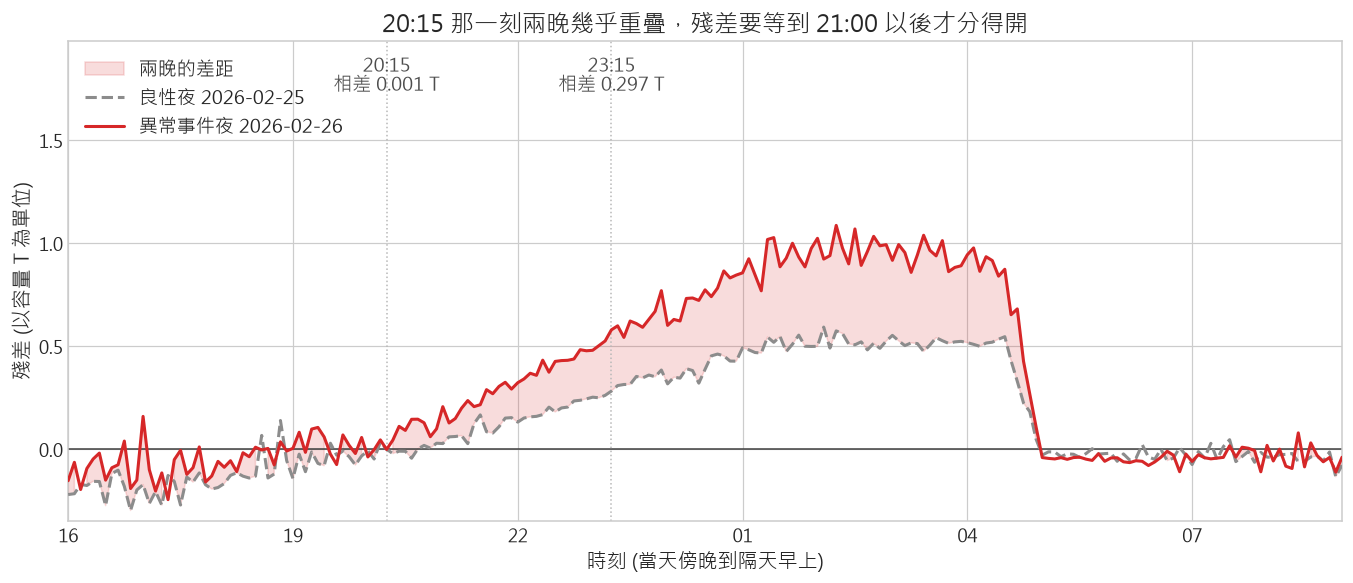


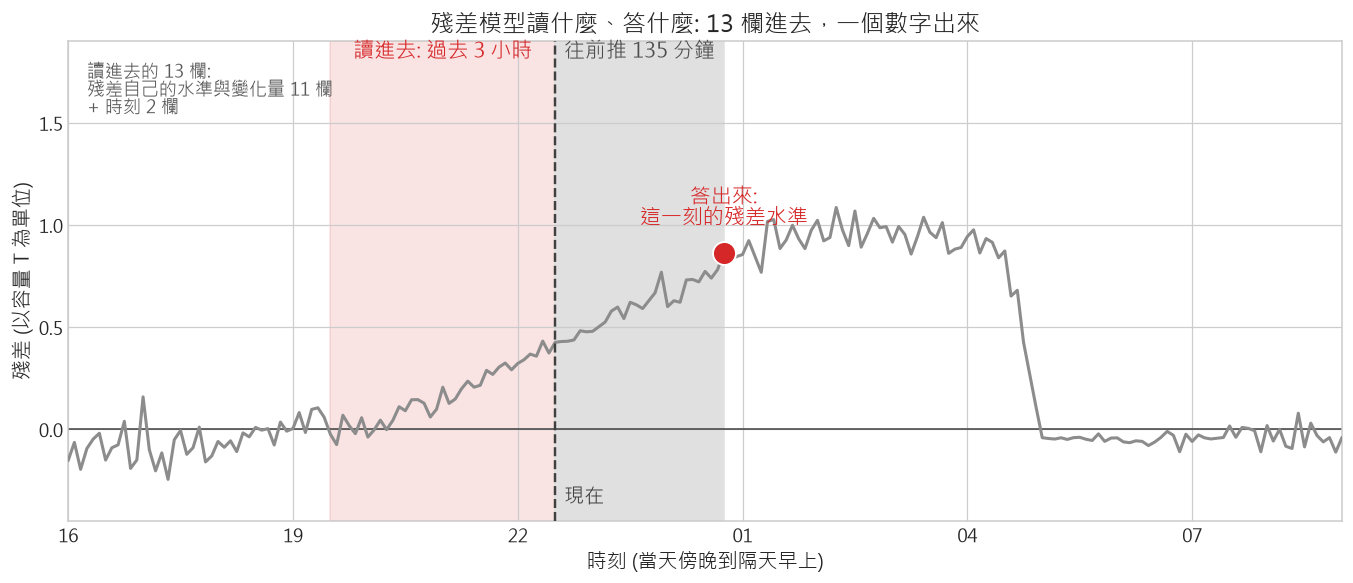

In [10]:
# 🎯 兩張圖回答兩個問題: 殘差自己夠不夠、模型實際上讀什麼答什麼。最後把殘差模型配出來。
# 📦 scikit-learn: 這一本只用它的 HistGradientBoostingRegressor (梯度提升樹)。
#    它跟 xgboost 做的事一樣，但它是 scikit-learn 內建的，課程環境不必多裝一個套件。
from sklearn.ensemble import HistGradientBoostingRegressor

# ============ ⚙️ 可調參數 ============
R_LAGS = (0, 3, 6, 12, 24, 42)   # 模型看得到「幾格前的殘差水準」。單位是格，一格 5 分鐘
R_SLOPES = (6, 18, 42, 72)       # 模型看得到「哪幾個尺度的殘差變化量」(30/90/210/360 分鐘)
                                 # 兩者調小: 模型只看得到最近十幾分鐘，長爬坡與短跳動長得一樣;
                                 # 調大: 欄數變多，而且最前面算不出來的列變多
CLIMB_W = 6                      # 「連續往上爬升了幾格」拿幾格前的值來比。6 格 = 30 分鐘
N_SEEDS = 5                      # 同一組設定用幾個亂數種子各配一個模型再取平均。
                                 # 這是為了穩定度不是準確度: 只配一個的話，同一份程式跑兩次
                                 # 的提前量實測會在 10 到 95 分鐘之間跳
GBM_KW = dict(max_iter=500, max_depth=6, learning_rate=0.05, l2_regularization=1.0)
                                 # 梯度提升樹的四個設定。調大: 訓練誤差更低，但跟著雜訊走的
                                 # 程度與配適時間都增加。h 掃描那一格刻意用同一組值
# ====================================


# ---- 1. 三個之後每一節都會用到的小工具 ----
def consecutive(mask, k=N_CONSEC):
    """連續 k 格都成立才算數。回傳一條同樣長度的 True/False。"""
    m = np.asarray(pd.Series(mask).fillna(False), bool)
    out = np.zeros(len(m), bool); run = 0
    for i, v in enumerate(m):
        run = run + 1 if v else 0
        out[i] = run >= k
    return out


def episodes(mask):
    """把連續的告警點併成一次呼叫，回傳呼叫次數，不是越線的取樣點數。
    這是講義 Alert Manager 三件事 (去重、分群、路由) 裡的第一件。"""
    m = np.asarray(pd.Series(mask).fillna(False), bool)
    return int(m[0]) + int(np.sum(m[1:] & ~m[:-1])) if len(m) else 0


def robust_limits(v):
    """穩健的中心與散布: 中位數與 MAD，不會被少數極端點拉走。
    MAD 乘 1.4826 之後對常態資料會收斂到標準差。"""
    v = np.asarray(v, float); v = v[np.isfinite(v)]
    c = float(np.median(v))
    return c, max(1.4826 * float(np.median(np.abs(v - c))), 1e-9)


# ---- 2. 第一張圖: 兩晚的殘差攤在同一條時鐘軸上，中間那一塊就是「分不分得開」 ----
g_ref = port_forecast(PRIMARY_PORT)
NG = g_ref.merge(features[features.port_id == PRIMARY_PORT].sort_values("timestamp")
                 .rename(columns={"timestamp": "ds"})[["ds"]], on="ds")


def night_of(day, hours=VIEW_HOURS):
    """取 day 那天 16:00 起算的 hours 小時，並加一欄 h = 16:00 起算第幾個小時。"""
    a = pd.Timestamp(day) + pd.Timedelta(hours=VIEW_START_HOUR)
    w = NG[(NG.ds >= a) & (NG.ds <= a + pd.Timedelta(hours=hours))].copy()
    w["h"] = (w.ds - a).dt.total_seconds() / 3600.0
    return w


def night_axis(ax, hours=VIEW_HOURS, step=3):
    """把 h 軸的刻度寫回時鐘時間 (16, 19, ... 隔天 09)。"""
    ax.set_xlim(0, hours); ax.set_xticks(range(0, hours + 1, step))
    ax.set_xticklabels([f"{(VIEW_START_HOUR + k) % 24:02d}"
                        for k in range(0, hours + 1, step)], fontsize=11)


B_NIGHT, K_NIGHT = night_of("2026-02-25"), night_of("2026-02-26")
rb, rk = B_NIGHT.residual.values / T_CASE, K_NIGHT.residual.values / T_CASE   # 以 T 為單位

fig, ax = plt.subplots(figsize=(12.4, 5.4), dpi=110)
ax.fill_between(K_NIGHT.h, rb, rk, where=(rk >= rb), color=ACC, alpha=0.16, zorder=1,
                label="兩晚的差距")
ax.axhline(0, color=INK, lw=1.0, zorder=2)
ax.plot(B_NIGHT.h, rb, color=GREY, ls="--", lw=2.0, zorder=3, label="良性夜 2026-02-25")
ax.plot(K_NIGHT.h, rk, color=ACC, ls="-", lw=2.0, zorder=3, label="異常事件夜 2026-02-26")
ax.set_ylim(-0.35, 1.98)
# 圖上兩個數字都用內插從資料算出來，不寫死。RAMP_H 是 20:00 的位置。
gap_early = abs(float(np.interp(RAMP_H + 0.25, K_NIGHT.h, rk)
                      - np.interp(RAMP_H + 0.25, B_NIGHT.h, rb)))
gap_late = abs(float(np.interp(RAMP_H + 3.25, K_NIGHT.h, rk)
                     - np.interp(RAMP_H + 3.25, B_NIGHT.h, rb)))
for hx, gap, lab in ((RAMP_H + 0.25, gap_early, "20:15"),
                     (RAMP_H + 3.25, gap_late, "23:15")):
    ax.axvline(hx, color="0.72", lw=1.0, ls=":", zorder=2)
    ax.text(hx, 1.74, f"{lab}\n相差 {gap:.3f} T", ha="center", fontsize=12.5, color="0.30")
night_axis(ax)
ax.set_xlabel("時刻 (當天傍晚到隔天早上)", fontsize=13)
ax.set_ylabel("殘差 (以容量 T 為單位)", fontsize=13)
ax.tick_params(labelsize=11.5); ax.legend(loc="upper left", fontsize=12.5, framealpha=0.95)
ax.set_title("20:15 那一刻兩晚幾乎重疊，殘差要等到 21:00 以後才分得開", fontsize=15.5)
plt.tight_layout(); show_fig(fig)


# ---- 3. 設計矩陣: 13 欄，全部來自殘差自己與時刻 ----
#         6 欄殘差的近期水準 + 4 欄殘差的變化量 + 1 欄連續往上爬升幾格 + 2 欄時刻的 sin/cos。
#         殘差全部除以該 port 自己的容量 T，所以五個 port 疊得起來。
def climb_runlen(r, w=CLIMB_W):
    """連續往上爬升了幾格。單一個數字就把「一路漲」跟「漲跌互見」分開。"""
    sl = np.full(len(r), np.nan); sl[w:] = r[w:] - r[:-w]
    up = np.nan_to_num(sl, nan=0.0) > 0
    out = np.zeros(len(r)); run = 0
    for i, v in enumerate(up):
        run = run + 1 if v else 0
        out[i] = run
    return out


def build_features_for(pid):
    """回傳 (13 欄的設計矩陣, 標出哪幾列在訓練期的 True/False, 13 個欄名)。"""
    g = port_forecast(pid)
    d = features[features.port_id == pid].sort_values("timestamp").reset_index(drop=True)
    r = g["residual"].values.astype(float) / CAPACITY[pid]
    cols, names = [], []
    for L in R_LAGS:                    # 往後挪 L 格，所以第 i 列拿到的是 L 格之前的值
        c = np.full(len(r), np.nan); c[L:] = r[:len(r) - L] if L else r
        cols.append(c); names.append(f"r_lag{L}")
    for w in R_SLOPES:                  # 這一格與 w 格前的差
        c = np.full(len(r), np.nan); c[w:] = r[w:] - r[:-w]
        cols.append(c); names.append(f"slope{w * 5}min")
    cols.append(climb_runlen(r)); names.append("climb_runlen")
    # 時刻用 sin/cos 一組表示，23:55 與 00:00 才會是相鄰的兩個值。
    hod = d.timestamp.dt.hour.values + d.timestamp.dt.minute.values / 60
    cols += [np.sin(2 * np.pi * hod / 24), np.cos(2 * np.pi * hod / 24)]
    names += ["sin_tod", "cos_tod"]
    return np.column_stack(cols), (d.timestamp < TRAIN_END).values, names


def target_for(pid, h_step=H_STEP):
    """要預測的量: 未來 h 格那一刻的殘差水準本身，以 T 為單位。"""
    r = port_forecast(pid)["residual"].values.astype(float) / CAPACITY[pid]
    y = np.roll(r, -h_step)            # 整條往前挪 h 格，每一列就對到自己未來的那個值
    y[-h_step:] = np.nan               # 最後 h 格沒有未來可看
    return y


# ---- 4. 五個 port 疊成一張訓練表，只用 TRAIN_END 之前的列 ----
#         loss 與 quantile 是留給「區間」那一節的: 預設的 squared_error 學的是平均值，
#         換成 quantile 之後學的是分位數，配一個 q=0.05 當下界、一個 q=0.95 當上界，
#         兩條線之間就是一個區間，不必先假設誤差是常態分布。
def train_residual_model(h_step=H_STEP, loss="squared_error", quantile=None,
                         n_seeds=None, cache={}):
    n_seeds = N_SEEDS if n_seeds is None else n_seeds
    key = (h_step, loss, quantile, n_seeds)
    if key in cache:
        return cache[key]
    Xs, Ys, Ts = [], [], []
    for pid in ALL_PORT_IDS:
        X, trm, names = build_features_for(pid)
        Xs.append(X); Ys.append(target_for(pid, h_step)); Ts.append(trm)
    X = np.vstack(Xs); Y = np.concatenate(Ys); tr = np.concatenate(Ts)
    ok = tr & np.isfinite(Y) & np.isfinite(X).all(1)     # 訓練期、且特徵與目標都齊的列
    models = []
    for seed in range(n_seeds):
        kw = dict(GBM_KW, random_state=seed, loss=loss)
        if quantile is not None:
            kw["quantile"] = quantile
        models.append(HistGradientBoostingRegressor(**kw).fit(X[ok], Y[ok]))
    cache[key] = (models, names, int(ok.sum()))
    return cache[key]


def predict_resid(models, X):
    """整組模型的平均預測，單位是 T 的倍數。預測時每一列都要有答案，所以 nan 換成 0。"""
    return np.mean([m.predict(np.nan_to_num(X)) for m in models], axis=0)


def project_at(pid, models, h_step=H_STEP):
    """未來流量推算值 = 未來那一刻的季節基準 + 模型預測的那一刻的殘差水準。

    兩項都先除以 T 再相加，最後整個乘回 T，所以回傳值可以直接跟容量門檻比大小。"""
    g = port_forecast(pid)
    T = CAPACITY[pid]
    base = g["yhat"].shift(-h_step).values / T
    return np.maximum((base + predict_resid(models, FEATURE_CACHE[pid])) * T, 0.0)


RESID_MODELS, FEAT_NAMES, N_TRAIN = train_residual_model()
FEATURE_CACHE = {pid: build_features_for(pid)[0] for pid in ALL_PORT_IDS}

# ---- 5. 第二張圖: 同一條時間序列上，模型讀哪一段、答哪一點 ----
r_k = K_NIGHT.residual.values / T_CASE
t_now, t_out = RAMP_H + 2.5, RAMP_H + 2.5 + H_MIN / 60   # 站在 22:30，答 135 分鐘後那一點
fig, ax = plt.subplots(figsize=(12.4, 5.4), dpi=110)
ax.axvspan(t_now - 3.0, t_now, color=ACC, alpha=0.13, zorder=0)     # 讀進去的那一段
ax.axvspan(t_now, t_out, color="0.88", zorder=0)                    # 預測跨度
ax.axhline(0, color=INK, lw=1.0, zorder=1)
ax.plot(K_NIGHT.h, r_k, color=GREY, lw=2.0, zorder=3)
ax.axvline(t_now, color=INK, lw=1.6, ls="--", zorder=4)
v_out = float(np.interp(t_out, K_NIGHT.h, r_k))
ax.plot([t_out], [v_out], marker="o", ms=15, color=ACC, zorder=6,
        markeredgecolor="white", markeredgewidth=1.2)
ax.set_ylim(-0.45, 1.90)
ax.text(t_now - 1.5, 1.82, "讀進去: 過去 3 小時", ha="center", fontsize=14, color=ACC)
ax.text(0.25, 1.80, "讀進去的 13 欄:\n殘差自己的水準與變化量 11 欄\n+ 時刻 2 欄",
        ha="left", fontsize=11.5, color="0.35", va="top")
ax.text((t_now + t_out) / 2, 1.82, f"往前推 {H_MIN} 分鐘", ha="center", fontsize=14, color="0.30")
ax.text(t_out, v_out + 0.14, "答出來:\n這一刻的殘差水準", ha="center", fontsize=13.5, color=ACC)
ax.text(t_now + 0.12, -0.32, "現在", fontsize=13, color=INK, va="center")
night_axis(ax)
ax.set_xlabel("時刻 (當天傍晚到隔天早上)", fontsize=13)
ax.set_ylabel("殘差 (以容量 T 為單位)", fontsize=13)
ax.tick_params(labelsize=11.5)
ax.set_title(f"殘差模型讀什麼、答什麼: {len(FEAT_NAMES)} 欄進去，一個數字出來", fontsize=15.5)
plt.tight_layout(); show_fig(fig)


In [11]:
# 🎯 這個殘差模型到底長什麼樣: 讀幾列、幾個特徵、答哪一個量。
#    這一格不算東西，只是把上面配好的模型規格排成一張表。
display(pd.DataFrame({"殘差模型": {
    "訓練列數 (五個 port 疊起來)": f"{N_TRAIN:,}",
    "特徵數": len(FEAT_NAMES),
    "特徵名稱": "、".join(FEAT_NAMES),
    "預測的量": f"未來 {H_MIN} 分鐘的殘差水準 (以 T 為單位)"}}))


,殘差模型
訓練列數 (五個 port 疊起來),"32,760"
特徵數,13
特徵名稱,r_lag0、r_lag3、r_lag6、r_lag12、r_lag24、r_lag42、slope30min、slope90min、slope210min、slope360min、climb_runlen、sin_tod、cos_tod
預測的量,未來 135 分鐘的殘差水準 (以 T 為單位)


---

## 兩個設定值一起挑: 往前看多久，以及連續幾格才預警

#### 前面每一張圖都寫著 135 分鐘與連續 4 格

- **horizon $h$ 是這個模型往前看多久。** 該預警的那一刻是越線前 $h$ 分鐘，所以事故必須在那之前就已經開始爬升，模型才有東西可讀
- **`N_CONSEC` 是推算值要連續幾個取樣點都指向越線，才算一次預警。** 5 分鐘一格，所以連續 4 格就是連續 20 分鐘

#### 挑法有先後順序，從業務的角度出發

1. **先問「收到預警之後，處置要花多久」。** 這段業務處理時間就是 $h$ 的下限，資料回答不了它。這一章假設是「至少要一小時」，有了這個下限，再回頭看爬坡有多長，$h$ 才定得出來
2. **再問「一天處理得完幾次預警」。** 這個次數就是 `N_CONSEC` 的評量標準: 處理得完的次數越少，預警就要越不敏感，`N_CONSEC` 要設得越大



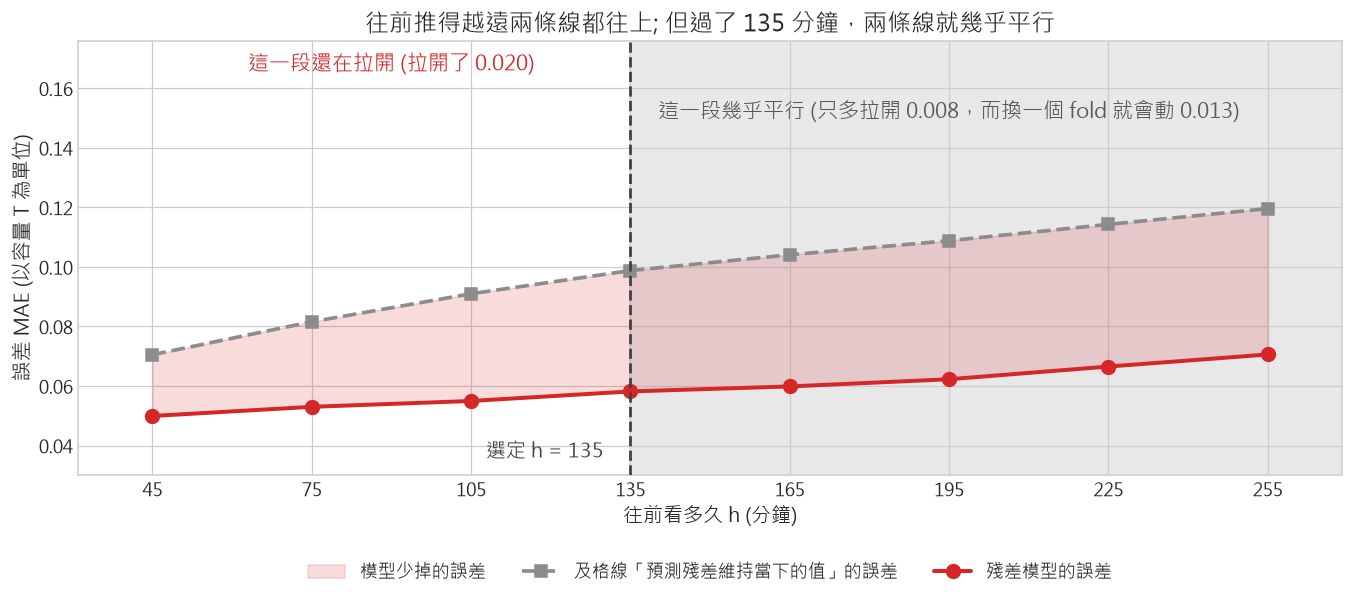

In [12]:
# 🎯 h 掃描: 往後推得越遠，模型與及格線的誤差各爬升到多少。

# ============ ⚙️ 可調參數 ============
H_GRID = [45, 75, 105, 135, 165, 195, 225, 255]   # 要放在同一張圖上比的 horizon (分鐘)。
                                                  # 兩端要拉得夠開才看得出轉折
N_FOLDS, FOLD_DAYS = 4, 2   # 驗證切成幾個 fold、每個 fold 驗證幾天。四個 fold 的落差
                            # (SPREAD) 就是這一格唯一量得到的「同一個 h 換一個 fold 會差多少」，
                            # 所以 fold 數不要降到 1
# ====================================
# fold 的切法: 每個 fold 只用「這個 fold 開始之前」的資料訓練，驗證接下來兩天，
# 再把切點往後推兩天。時間序列不能隨機切，隨機切等於拿未來配過去。
# 最後一個 fold 的切點就是 TRAIN_END。
FOLD_STARTS = [TRAIN_END - pd.Timedelta(days=FOLD_DAYS * k) for k in range(N_FOLDS, 0, -1)]


# ---- 1. 一個 fold、一個 h: 回傳模型的 MAE，以及「預測殘差維持當下的值」這條及格線的 MAE ----
#         兩個數字愈接近，代表在這個 h 上，配一個模型愈換不到什麼。
#         這裡的模型設定刻意與正式的殘差模型完全相同 (GBM_KW)，一改，掃出來的差就變成
#         「模型設定的差」，不再是「horizon 的差」。
def scan_one_h(h_min, fold_start):
    hs = h_min // 5
    fold_end = fold_start + pd.Timedelta(days=FOLD_DAYS)
    Xtr, ytr, Xva, yva, base = [], [], [], [], []
    for pid in ALL_PORT_IDS:
        g = port_forecast(pid)
        r = g["residual"].values.astype(float) / CAPACITY[pid]
        y = np.roll(r, -hs); y[-hs:] = np.nan       # 目標: h 分鐘之後的殘差水準
        X = FEATURE_CACHE[pid]
        ok = np.isfinite(y) & np.isfinite(X).all(1)
        tr = ok & (g.ds < fold_start).values                              # 訓練: 切點之前
        va = ok & (g.ds >= fold_start).values & (g.ds < fold_end).values  # 驗證: 之後兩天
        Xtr.append(X[tr]); ytr.append(y[tr])
        Xva.append(X[va]); yva.append(y[va])
        base.append(r[va])                          # 及格線: 直接拿現在的殘差當答案
    m = HistGradientBoostingRegressor(**GBM_KW, random_state=0)
    m.fit(np.vstack(Xtr), np.concatenate(ytr))
    p = m.predict(np.nan_to_num(np.vstack(Xva)))
    yva = np.concatenate(yva)
    return float(np.mean(np.abs(p - yva))), float(np.mean(np.abs(np.concatenate(base) - yva)))


# ---- 2. 八個 h 全部跑一遍，再彙總成一個 h 一列 ----
#         八個 h 各配四個 fold，共 32 個模型。一個 h 只用一個種子，因為要比的是 h 與 h 之間的差。
scan = pd.DataFrame([{"h": h, "mae_model": mm, "mae_base": mb}
                     for h in H_GRID for f in FOLD_STARTS
                     for mm, mb in [scan_one_h(h, f)]])
scan["gap"] = scan.mae_base - scan.mae_model      # 模型比及格線少掉的誤差
agg = scan.groupby("h").agg(mae_model=("mae_model", "mean"), mae_base=("mae_base", "mean"),
                            gap=("gap", "mean"), gap_lo=("gap", "min"), gap_hi=("gap", "max"))
# 三個數字要一起讀: RISE 是訊號 (拉長 h 真的換到東西)，SPREAD 是這份資料的量測誤差。
# FLAT 小於等於 SPREAD 的話，H_MIN 之後那幾個 h 的差就是量不出來的。
RISE = float(agg.gap[H_MIN] - agg.gap.iloc[0])
FLAT = float(agg.gap.iloc[-1] - agg.gap[H_MIN])
SPREAD = float(agg.gap_hi[H_MIN] - agg.gap_lo[H_MIN])

# ---- 3. 畫圖: 兩條誤差線都往上，但過了 H_MIN 之後就幾乎平行 ----
fig, ax = plt.subplots(figsize=(12.4, 5.6), dpi=110)
ax.axvspan(H_MIN, H_GRID[-1] + 14, color="0.91", zorder=0)   # 「不再拉開」的那一段
ax.fill_between(agg.index, agg.mae_model, agg.mae_base, color=ACC, alpha=0.16, zorder=1,
                label="模型少掉的誤差")
ax.plot(agg.index, agg.mae_base, color=GREY, lw=2.4, ls="--", marker="s", ms=8, zorder=3,
        label="及格線「預測殘差維持當下的值」的誤差")
ax.plot(agg.index, agg.mae_model, color=ACC, lw=2.6, marker="o", ms=9, zorder=4,
        label="殘差模型的誤差")
ax.axvline(H_MIN, color=INK, lw=1.8, ls="--", zorder=5)
ax.set_ylim(0.030, 0.176)                       # 上緣留白給底下那兩行說明
ax.set_xticks(H_GRID); ax.set_xlim(H_GRID[0] - 14, H_GRID[-1] + 14)
ax.set_xlabel("往前看多久 h (分鐘)", fontsize=13)
ax.set_ylabel("誤差 MAE (以容量 T 為單位)", fontsize=13)
ax.tick_params(labelsize=11.5)
ax.text((H_GRID[0] + H_MIN) / 2, 0.166, f"這一段還在拉開 (拉開了 {RISE:.3f})",
        ha="center", fontsize=13.5, color=ACC)
ax.text((H_MIN + H_GRID[-1]) / 2, 0.150,
        f"這一段幾乎平行 (只多拉開 {FLAT:.3f}，而換一個 fold 就會動 {SPREAD:.3f})",
        ha="center", fontsize=13.5, color="0.35")
ax.text(H_MIN - 5, 0.036, f"選定 h = {H_MIN}", ha="right", fontsize=13, color=INK)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, fontsize=12,
          framealpha=0.95)
ax.set_title(f"往前推得越遠兩條線都往上; 但過了 {H_MIN} 分鐘，兩條線就幾乎平行",
             fontsize=15.5)
plt.tight_layout(); show_fig(fig)


#### 到這裡模型就定案了

- **殘差模型要學的是「不正常正在往哪裡走」，而往前看多久 (h) 就是這張圖在挑的東西。** 八個 h 各配一組模型比下來，過了 135 分鐘兩條線只多拉開 0.009，比同一個 h 換一個 fold 就會動的 0.013 還小，再往前推換不到量得出來的準度; 而 135 分鐘同時也在「至少一小時處置」這個下限之上。h 一定下來，前面用 h = 135 配好的那個殘差模型，就是後面每一節都在用的那一個。
- **接下來挑 `N_CONSEC` 不會再重配模型。** 它調的是怎麼讀模型算出來的推算值: 要連續幾格都指向越線才送出一則通知，也就是這條規則要多敏感、一天發得出幾則，那是維運一天收得下多少決定的。

---

### 連續幾格才預警

- 要求連續的理由在這份資料上量得出來: 這個 port 30 天裡單格越過 $T$ 有一百多次，白天是日常。只要一格就預警，預警系統每天中午都會送出一則。
- 但 4 這個數字本身也要用資料看過: 掃一遍，看每一個值在切點左邊少掉多少誤警、又賠掉多少提前量。

**下一格分成兩段。** 第一段先立一把評分的尺: 哪些事件算數、什麼叫「來得及」、誤警怎麼算。要比較兩組設定值就得先有這把尺，而驗證那一節用的是同一把,所以它定義在這裡、只定義一次。第二段才拿它把 1 到 12 格各評一次。


In [13]:
# 🎯 先立一把評分的尺，再用它掃「連續幾格才預警」。

# ============ ⚙️ 可調參數 ============
LEAD_WINDOW = pd.Timedelta(minutes=H_MIN)   # 「提前多久預警才算來得及」，刻意設成跟 h 一樣長。
                                            # 調大: 更早的預警也算命中，但那是尺放寬了不是規則變好
N_CONSEC_GRID = [1, 2, 3, 4, 5, 6, 8, 12]     # 要掃的「連續幾格」候選清單 (調的不是 N_CONSEC 本身)
# 底下兩個名單是從事件目錄抄下來的，是資料的性質不是設定值: 換一份資料就要重寫。
BENIGN_IDS = {"K_BENIGN", "N"}       # 良性對照: 這兩個發出預警就是錯的
RAMP_IDS = {"K", "M"}                # 斜坡型: 有前兆可以外推，預警才有可能抓到
# ====================================


# ---- 1. 十七個事件先分成三堆: 進分母的、預警了就是錯的、其餘 ----
def affected_ports(ev):
    """這個事件實際打到哪幾個 port。MULTI 事件由模擬器逐列注入的 event_id 決定。"""
    if ev.port_id != "MULTI":
        return [ev.port_id]
    w = features[(features.timestamp >= ev.start_time) & (features.timestamp <= ev.end_time)
                 & (features.event_id == ev.event_id)]
    return sorted(w.port_id.unique())


# ALL_PAIRS 保留全部十七個事件。它不是拿來算召回率的，是算誤警率時要蓋掉的區間:
# 階梯型事件的時段雖然不進分母，那段時間也不算「沒有事件」。
ALL_PAIRS = [(ev, p) for _, ev in event_catalog.iterrows() for p in affected_ports(ev)]
RAMP_PAIRS = [(ev, p) for ev, p in ALL_PAIRS if ev.event_id in RAMP_IDS]
BENIGN_PAIRS = [(ev, p) for ev, p in ALL_PAIRS if ev.event_id in BENIGN_IDS]


# ---- 2. 事件變成問題的那一刻。提前量與命中都是拿它當原點量的 ----
def problem_time(tracks, ev, p):
    """事件變成問題的那一刻。斜坡是越線的時候，不是開始爬升的時候。
    找不到越線點 (例如量沒有真的超出容量) 就退回事件開始時間。"""
    g = tracks[p]
    w = ((g.ds >= ev.start_time) & (g.ds <= ev.end_time) & (g["y"] >= CAPACITY[p])).values
    return g.loc[w, "ds"].iloc[0] if w.any() else ev.start_time


# ---- 3. 評分的尺。要比較兩組設定值，得先講定什麼叫「抓到了」 ----
#         驗證那一節用的是同一把尺，所以定義只寫在這裡一次。
def evaluate(tracks, pairs, col="alert", far_before=None):
    """講義那四個預警指標，加上提前量。
    TP = 事件在變成問題之前就發出預警; FN 含漏警與太晚預警; FP 以預警段計次。"""
    tp = late = fn = 0
    leads = []
    for ev, p in pairs:
        g = tracks[p]
        m = g[col].astype(bool).values
        ts = g["ds"].values
        ref = problem_time(tracks, ev, p)
        # 一個事件只有三種下場: 在越線前那個預警窗裡預警過就是及時 (TP)，
        # 只在越線之後預警過就是太晚，兩段都沒有就是漏掉。
        pre = (ts >= np.datetime64(ref - LEAD_WINDOW)) & (ts < np.datetime64(ref))
        dur = (ts >= np.datetime64(ref)) & (ts <= np.datetime64(ev.end_time))
        if (m & pre).any():
            tp += 1
            leads.append((ref - pd.Timestamp(ts[m & pre][0])).total_seconds() / 60)
        elif (m & dur).any():
            late += 1
        else:
            fn += 1
    # 誤警在全部五個 port、全部沒有事件的時間上算一次。事件視窗要連同前一個預警窗一起
    # 蓋掉: 那裡發出的預警是 TP 的材料，不能再算成誤警。
    fp_pts = ic_pts = fp_eps = 0
    for p, g in tracks.items():
        m = g[col].astype(bool).values
        ts = g["ds"].values
        covered = np.zeros(len(ts), bool)
        for ev, q in ALL_PAIRS:
            if q == p:
                covered |= ((ts >= np.datetime64(ev.start_time - LEAD_WINDOW))
                            & (ts <= np.datetime64(ev.end_time)))
        keep = ~covered
        if far_before is not None:
            keep &= ts < np.datetime64(far_before)
        # 兩種數法都要: fp_pts 數的是「幾格在預警」，fp_eps 把連續的格子併成一次通知。
        fp_pts += int((m & keep).sum()); ic_pts += int(keep.sum())
        fp_eps += episodes(m & keep)
    far = fp_pts / max(ic_pts, 1)
    # 隨機基準: 一個誤警率同樣是 far 的隨機告警器，在一個預警窗之內至少預警一次的機率。
    n_slots = int(LEAD_WINDOW / pd.Timedelta("5min"))
    return {"Event Recall": tp / max(tp + late + fn, 1),
            "False Alarm Rate": far, "誤警段數": fp_eps,
            "誤警點數": fp_pts, "無事件點數": ic_pts,
            "Avg Lead Time (min)": float(np.mean(leads)) if leads else float("nan"),
            "最短提前量 (min)": float(np.min(leads)) if leads else float("nan"),
            "_chance": 1 - (1 - far) ** n_slots}


# ---- 4. 掃描用的推算值。這裡只要 proj 這一欄，區間與分級是下一節的事 ----
TRACKS = {}
for pid in ALL_PORT_IDS:
    t = port_forecast(pid)[["ds", "y"]].copy()
    t["proj"] = project_at(pid, RESID_MODELS)
    TRACKS[pid] = t

# ---- 5. 連續幾格才預警: 1 到 12 格各評一次，其餘設定完全不動 ----
#         這一格不重配任何東西。兩個模型與門檻 T 在上一節就定完了，這裡只是把同一條推算線
#         套上八種連續格數，觀察規則的行為怎麼變，再拿去對維運的需求。
#         提前量的材料是「越線事件」: 切點左邊已公告的夜間活動裡，實際流量真的越過 T 的
#         那幾晚。它們不是故障，但爬坡與越線都是真的，所以「這條規則多早講得出來」量得到。
#         斜坡型事故 (K、M) 不進這張表: 整份資料只有 2 個而且都在切點右邊，拿它們挑設定
#         值，驗證那一節就沒有東西可以驗了。
CROSS_PAIRS = []          # (視窗, port): 切點左邊已公告的夜間活動裡，實際值真的越過 T 的那幾段
for _, s in schedule[(schedule.start_time < TRAIN_END)
                     & schedule.kind.isin(BULK_TRANSFER_KINDS)].iterrows():
    w = TRACKS[s.port_id]
    if ((w.ds >= s.start_time) & (w.ds <= s.end_time) & (w["y"] >= CAPACITY[s.port_id])).any():
        CROSS_PAIRS.append((s, s.port_id))
N_CROSS = len(CROSS_PAIRS)
BENIGN_EARLY_PAIRS = [(ev, p) for ev, p in BENIGN_PAIRS if ev.end_time < TRAIN_END]
rows_k = []
for k in N_CONSEC_GRID:
    col = f"alert_k{k}"
    for pid, t in TRACKS.items():
        t[col] = consecutive(t["proj"] >= CAPACITY[pid], k=k)
    # 同一把尺，只是餵進去的是越線事件而不是事故; 誤警那一半跟餵什麼無關。
    r = evaluate(TRACKS, CROSS_PAIRS, col=col, far_before=TRAIN_END)
    lo = r["最短提前量 (min)"]
    # 切點左邊唯一的良性對照 (事件 N 的多週良性成長) 在它的時段內預警了幾點，應該是 0。
    bad = sum(int(TRACKS[p].loc[((TRACKS[p].ds >= ev.start_time)
                                 & (TRACKS[p].ds <= ev.end_time)).values, col].sum())
              for ev, p in BENIGN_EARLY_PAIRS)
    rows_k.append({"連續幾格": k, "等於幾分鐘": k * 5,
                   "切點前誤警率": round(r["False Alarm Rate"], 4),
                   "切點前誤警段數": r["誤警段數"],
                   f"越線事件抓到幾件 (共 {N_CROSS})": int(round(r["Event Recall"] * N_CROSS)),
                   "最短提前量 (分)": ("沒有預警" if not np.isfinite(lo) else round(lo)),
                   "良性成長預警了幾點 (應為 0)": bad})

display(pd.DataFrame(rows_k).set_index("連續幾格"))


,等於幾分鐘,切點前誤警率,切點前誤警段數,越線事件抓到幾件 (共 6),最短提前量 (分),良性成長預警了幾點 (應為 0)
連續幾格,,,,,,
1,5,0.0101,73,6,45,0
2,10,0.0074,41,5,100,0
3,15,0.0059,30,5,75,0
4,20,0.0048,13,5,70,0
5,25,0.0044,11,5,65,0
6,30,0.0040,6,3,75,0
8,40,0.0035,6,3,65,0
12,60,0.0027,5,2,45,0


#### 每往右一格，誤警變少，能提早講出來的時間也變少

- **連續 1 格 (也就是不要求連續)**: 切點左邊就有 70 段誤警。23 天、五個 port 加起來平均一天三則
- **3 格到 4 格是誤警掉幅最大的一段**: 31 段掉到 14 段，砍掉超過一半; 過了 4 格就平了，14 到 13、9、7、5，一格只換得到幾段
- **右邊兩欄同時在變差**: 最短提前量 4 格是 70 分、5 格 65 分，到 12 格只剩 45 分; 越線事件抓到的件數也從 6 件掉到 5、4、3、2 件
- **良性成長那一欄從頭到尾是 0**: 事件 N 是連續兩週的良性容量成長，切點左邊唯一一段「趨勢真的往上、但不該預警」的資料

#### 利用一天能處理多少預警以及資料與模型的互動模式選出 N_CONSEC

- **這張表跟上一張圖一樣，沒有重配任何模型。** 兩個模型與門檻 $T$ 在上一節就定完凍住了，這裡只是把同一條推算值套上八種連續格數，看這條規則的敏感度怎麼變。
- **先用維運的兩個數字篩一次。** 一天收得下幾則: 1 格是 23 天、五個 port 合計 70 段，平均一天三則，收不下; 4 格降到 14 段，大約三天兩則。處置至少要一小時: 12 格的最短提前量只剩 45 分鐘，不到一小時，不用考慮。
- **剩下的看這張表怎麼走: 選 4 格。** 3 格到 4 格是誤警最後一次大量減少 (31 段到 14 段，少掉超過一半); 再往右每一格只少掉幾段 (13、9、7、5)，最短提前量與抓到的件數卻一路變小 (70 分鐘到 45 分鐘、5 件到 2 件)。4 格的 70 分鐘同時也還在「至少一小時處置」這個下限之上。

---

## 加上區間: 把一條線變成四個處置分級

##### 到這裡推算值只有一條線，它碰到 $T$ 只回答得了「預警或不預警」。

系統要的其實是三種深淺不同的說法: 
- 有機會碰到、預計會跨過、幾乎確定會跨過
- 所以下一格再配兩個模型，一個學下界、一個學上界，把一條線撐成一段區間。



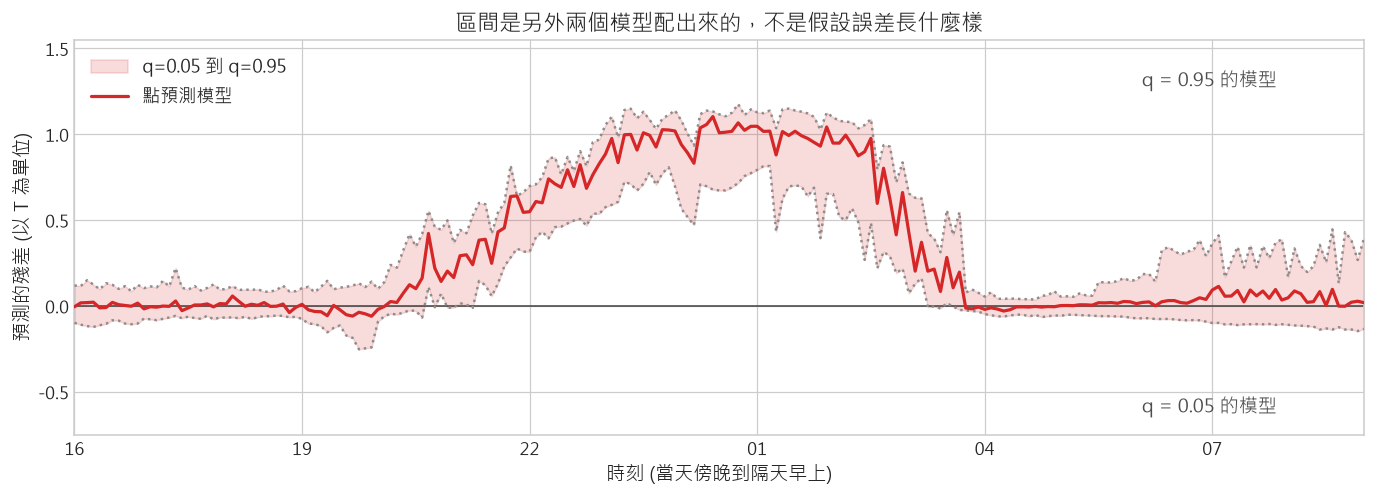


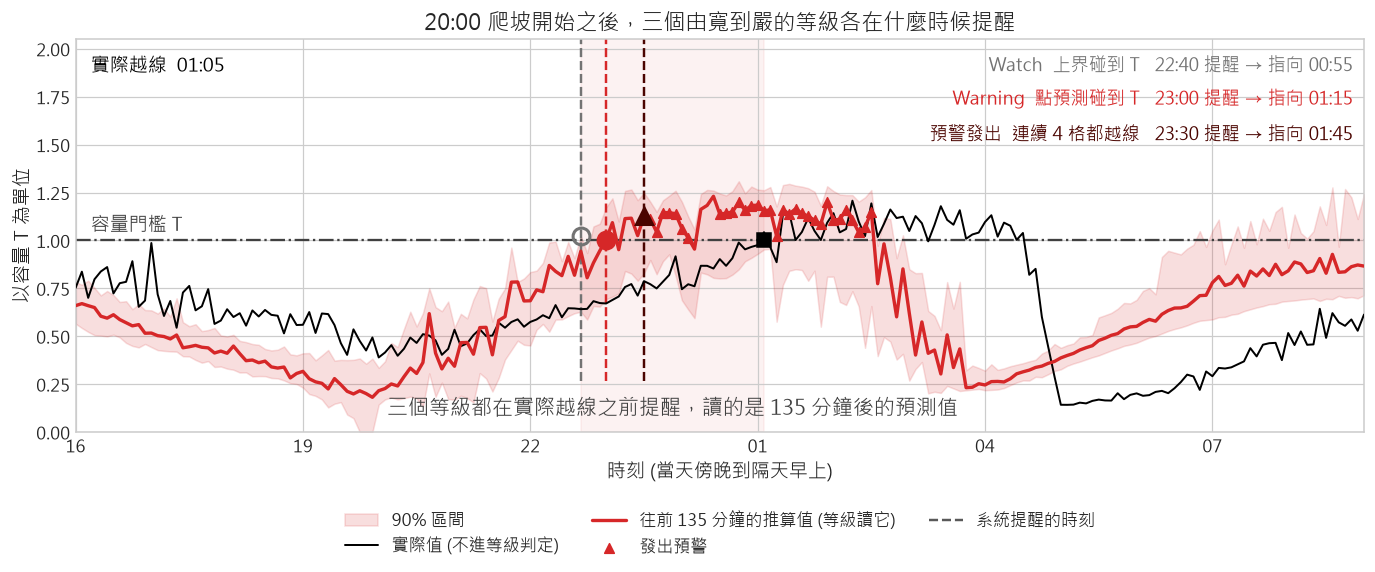

,30 天 x 五個 port
Info 的取樣點數,39545
Watch 的取樣點數,3179
Warning 的取樣點數,446
Critical 的取樣點數,30
區間的名目涵蓋率,90%
實測涵蓋率 (只算無事件的樣本),"89.1% (33,619 / 37,725)"


In [14]:
# 🎯 上下界各配一個分位數模型，把區間建出來，殘差模型到這裡就完成了。

# ============ ⚙️ 可調參數 ============
TAU_STEP = 15    # 「還有多久越線」這個答案的解析度 (分鐘)。15 分鐘一階，上限是 H_MIN。
                 # 改成 5: 答案更細，但 horizon 從九個變二十七個，配適時間跟著變三倍
QLO, QHI = 0.05, 0.95   # 區間的上下兩個分位數，中間夾住的就是名目 90%。
                        # 調窄 (0.10/0.90): Watch 的點數變少、Critical 變多; 調寬則相反。
                        # 改了的話底下 proj_sd 那一行的 Z90 一定要一起改
Z90 = 1.645      # 常態分布 90% 區間的半寬對應幾個標準差，只用來把區間換算成 p_exceed
RESID_Z, RESID_K = 3.0, 2   # 反應型告警 (交給 Lab 07 的那一欄): 殘差偏離幾個穩健標準差、
                            # 要連續幾格。3.0 沿用管制圖的慣例，這一章的成績表不評這一欄
# ====================================
TAU_HORIZONS = list(range(TAU_STEP, H_MIN + 1, TAU_STEP))      # 15, 30, ..., 135

# ---- 1. 三組模型: 點預測 (上一格已經配好)、兩個分位數、九個 tau horizon ----
#         這一格要配 (九個 horizon + 兩個分位數) x 五個種子，約兩分鐘。
#         分位數模型把 loss 換成 pinball loss，區間就不必假設誤差是常態的。
TAU_MODELS = {h: train_residual_model(h_step=h // 5)[0] for h in TAU_HORIZONS}
Q_MODELS = {q: train_residual_model(quantile=q, loss="quantile")[0] for q in (QLO, QHI)}


def risk_state(point, lower, upper, T):
    """四級的判定。由嚴到寬檢查，第一個成立的就是答案，所以四個等級互斥。"""
    if lower >= T: return "Critical"      # 連下界都越線
    if point >= T: return "Warning"       # 點預測越線
    if upper >= T: return "Watch"         # 只有上界越線
    return "Info"


# ---- 2. 一個 port 的完整結果表: 推算值、區間、四級、tau、以及匯出要的欄位 ----
def build_tracks(pid):
    g = port_forecast(pid).copy()
    T = CAPACITY[pid]
    g["capacity"] = T
    tr = (g.ds < TRAIN_END).values                     # 只有底下估管制界限時用到
    X = FEATURE_CACHE[pid]
    base = g["yhat"].shift(-H_STEP).values / T         # 未來那一刻的季節基準，以 T 為單位
    g["base_next"] = base

    # 三行的算法完全一樣 (季節基準 + 模型預測的殘差，再乘回 T)，差別只在用哪一組模型。
    g["r_hat"] = predict_resid(RESID_MODELS, X)
    g["proj"] = project_at(pid, RESID_MODELS)
    g["proj_lower"] = np.maximum((base + predict_resid(Q_MODELS[QLO], X)) * T, 0.0)
    g["proj_upper"] = np.maximum((base + predict_resid(Q_MODELS[QHI], X)) * T, 0.0)
    # 分位數模型只保證邊界的次序在整體上成立，個別列可能翻轉，夾一次。
    g["proj_lower"] = np.minimum(g["proj_lower"], g["proj"])
    g["proj_upper"] = np.maximum(g["proj_upper"], g["proj"])
    g["proj_sd"] = np.maximum((g["proj_upper"] - g["proj_lower"]) / (2 * Z90), 1.0)
    g["alert"] = consecutive(g["proj"] >= T)           # 預警: 連續 N_CONSEC 格都越線

    # tau: 最小的、推算值會跨過 T 的那個 horizon。每個 h 各一個模型，不是同一個模型外推。
    P = np.column_stack([
        np.maximum((g["yhat"].shift(-(h // 5)).values / T
                    + predict_resid(TAU_MODELS[h], X)) * T, 0.0) for h in TAU_HORIZONS])
    over = P >= T
    g["tau_min"] = np.where(over.any(1), np.take(TAU_HORIZONS, np.argmax(over, 1)), np.nan)

    # p_exceed: 把區間寬度換算成一個常態的散布，再算超過 T 的那一片面積。
    g["p_exceed"] = stats.norm.sf(T, loc=g["proj"].values, scale=g["proj_sd"].values)
    g["warning_level"] = [risk_state(a, b, c, T)
                          for a, b, c in zip(g.proj, g.proj_lower, g.proj_upper)]

    # 殘差的穩健管制界限。這一章的主線不用它，但 Lab 07 的匯出契約點名了這兩欄。
    # 它讀的是「已經發生的量」偏離平常多少，屬於偵測 (Lab 02 那一類)，不是預警。
    ctr, sg = robust_limits(g.loc[tr, "residual"])      # 中心與散布只從訓練期估
    g["resid_z"] = (g["residual"] - ctr) / sg
    g["reactive_alert"] = consecutive(g["resid_z"].abs() >= RESID_Z, k=RESID_K)
    return g


ALL_G = {pid: build_tracks(pid) for pid in ALL_PORT_IDS}
g_pri = ALL_G[PRIMARY_PORT]

# ---- 3. 第一張圖: 這條區間是哪裡來的 (兩個分位數模型各畫一條邊界) ----
a0 = pd.Timestamp("2026-02-26") + pd.Timedelta(hours=VIEW_START_HOUR)
wk = g_pri[(g_pri.ds >= a0) & (g_pri.ds <= a0 + pd.Timedelta(hours=VIEW_HOURS))].copy()
wk["h"] = (wk.ds - a0).dt.total_seconds() / 3600.0
q_lo = (wk.proj_lower / T_CASE - wk.base_next).values     # 減掉季節基準，三條才在同一尺度
q_hi = (wk.proj_upper / T_CASE - wk.base_next).values

fig, ax = plt.subplots(figsize=(12.6, 4.6), dpi=110)
ax.fill_between(wk.h, q_lo, q_hi, color=ACC, alpha=0.16, zorder=1, label="q=0.05 到 q=0.95")
ax.plot(wk.h, q_hi, color=GREY, lw=1.6, ls=":", zorder=3)
ax.plot(wk.h, q_lo, color=GREY, lw=1.6, ls=":", zorder=3)
ax.plot(wk.h, wk.r_hat.values, color=ACC, lw=2.1, zorder=4, label="點預測模型")
ax.axhline(0, color=INK, lw=1.0, zorder=2)
ax.set_ylim(-0.75, 1.55)
ax.text(VIEW_HOURS * 0.88, 1.28, f"q = {QHI} 的模型", fontsize=12.5, color="0.30", ha="center")
ax.text(VIEW_HOURS * 0.88, -0.62, f"q = {QLO} 的模型", fontsize=12.5, color="0.30", ha="center")
night_axis(ax)
ax.set_xlabel("時刻 (當天傍晚到隔天早上)", fontsize=12.5)
ax.set_ylabel("預測的殘差 (以 T 為單位)", fontsize=12.5)
ax.tick_params(labelsize=11); ax.legend(loc="upper left", fontsize=12, framealpha=0.95)
ax.set_title("區間是另外兩個模型配出來的，不是假設誤差長什麼樣", fontsize=14.5)
plt.tight_layout(); show_fig(fig)

# ---- 4. 第二張圖: 三個等級都讀預測值，而且都在實際越線之前 ----
#         推算值畫在算出它的那一刻 (跟最後那張單一事件圖同一個規則)，所以曲線碰到 T 的
#         那一格就是「系統在這一刻提醒」，而它講的是 H_MIN 分鐘之後的事:
#           虛線 = 系統提醒的時刻      標記 = 那一刻算出來的推算值
#         三個等級的判定全部落在推算值與它的區間上，實際值不進判定，它在圖上只負責
#         回答一件事: 提醒的當下，流量還沒有越線。
#         三個時刻一律從 20:00 起算: 白天的日間尖峰本來就會讓上界碰到 T。
fig, ax = plt.subplots(figsize=(12.6, 5.4), dpi=110)
T1 = 1.0                                            # 全部除以 T，所以門檻就是 1.0
night_wk = wk[wk.h >= RAMP_H]
LEVEL_MARKS = [
    ("Watch  上界碰到 T", night_wk[night_wk.proj_upper >= T_CASE], "0.45", "o", "none"),
    ("Warning  點預測碰到 T", night_wk[night_wk.proj >= T_CASE], ACC, "o", ACC),
    (f"預警發出  連續 {N_CONSEC} 格都越線", night_wk[night_wk.alert.values], "#4a0400", "^", "#4a0400"),
]
hits = [(lab, float(h.h.iloc[0]), h.ds.iloc[0], c, mk, mfc,
         float((h.proj_upper if "Watch" in lab else h.proj).iloc[0]) / T_CASE)
        for lab, h, c, mk, mfc in LEVEL_MARKS if not h.empty]
cross_a = night_wk[night_wk.y >= T_CASE]            # 實際值真正越線的那一刻
h_cross_a, ts_cross_a = float(cross_a.h.iloc[0]), cross_a.ds.iloc[0]

# 背景先畫: 從第一次提醒到實際越線的這一段，就是「還沒發生」的那一段。
ax.axvspan(hits[0][1], h_cross_a, color=ACC, alpha=0.06, zorder=0)
ax.fill_between(wk.h, wk.proj_lower / T_CASE, wk.proj_upper / T_CASE,
                color=ACC, alpha=0.15, zorder=1, label="90% 區間")
ax.axhline(T1, color=INK, ls="-.", lw=1.5, zorder=2)
ax.text(0.2, T1 + 0.05, "容量門檻 T", fontsize=12.5, color=INK, ha="left")
ax.plot(wk.h, wk.y / T_CASE, color="black", lw=1.3, zorder=3, label="實際值 (不進等級判定)")
ax.plot(wk.h, wk.proj / T_CASE, color=ACC, lw=2.2, zorder=4,
        label=f"往前 {H_MIN} 分鐘的推算值 (等級讀它)")

# 垂直線只有三條: 三個等級各自提醒的那一刻。線型跟最後那張圖一致 (虛線 = 提醒)，
# 下緣停在 13% 高度，最底下那一條帶留給結論那一句話。
for _, hx, _, colr, _, _, _ in hits:
    ax.axvline(hx, ymin=0.13, color=colr, lw=1.6, ls="--", zorder=2)
# 每一個等級的判定點畫在觸發它的那條預測線上 (Watch 在上界，另外兩個在點預測)，
# 所以一眼看得出來三個等級讀的都是預測值。
for _, hx, _, colr, mk, mfc, yv in hits:
    ax.plot([hx], [yv], marker=mk, ms=11, color=colr, mfc=mfc, mec=colr, mew=2.0, zorder=7)
# 實際越線那一刻畫在黑線上，跟上面三個判定點分得開。
ax.plot([h_cross_a], [T1], marker="s", ms=9, color="black", zorder=7)

al = wk[wk.alert.values]
ax.scatter(al.h, al.proj / T_CASE, s=40, color=ACC, marker="^", zorder=6, label="發出預警")
# 這一條沒有資料的線只是為了讓圖例說明虛線代表什麼。
ax.plot([], [], color="0.35", ls="--", lw=1.6, label="系統提醒的時刻")
ax.set_ylim(0, 2.05)
# 左上寫實際越線，右上三行寫三個等級，兩塊分開，中間不會互相壓到。
ax.text(0.2, 1.92, f"實際越線  {ts_cross_a:%H:%M}", fontsize=12.5, color="black", va="center")
for (lab, _, ts, colr, _, _, _), ytxt in zip(hits, [1.92, 1.74, 1.56]):
    ax.text(VIEW_HOURS - 0.15, ytxt,
            f"{lab}   {ts:%H:%M} 提醒 → 指向 {ts + pd.Timedelta(minutes=H_MIN):%H:%M}",
            fontsize=11.5, color=colr, va="center", ha="right")
ax.text((hits[0][1] + h_cross_a) / 2, 0.09,
        f"三個等級都在實際越線之前提醒，讀的是 {H_MIN} 分鐘後的預測值", ha="center",
        fontsize=13.5, color=INK)
night_axis(ax)
ax.set_xlabel("時刻 (當天傍晚到隔天早上)", fontsize=12.5)
ax.set_ylabel("以容量 T 為單位", fontsize=12.5)
ax.tick_params(labelsize=11)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, fontsize=11,
          framealpha=0.96)
ax.set_title("20:00 爬坡開始之後，三個由寬到嚴的等級各在什麼時候提醒", fontsize=14.5)
plt.tight_layout(); show_fig(fig)

# ---- 5. 涵蓋率: 實際值落在區間裡面的比例 ----
#         對齊很容易寫錯: 每一列的區間是站在 H_STEP 格「之前」做出來的預測，
#         所以要把它往後挪 H_STEP 格，才跟同一列的實際值講的是同一個時刻。
#         只算沒有被事件動過的樣本: 事件本來就該落在區間外面。
tot = ins = 0
for pid, g in ALL_G.items():
    lab = (features[features.port_id == pid].rename(columns={"timestamp": "ds"})
           [["ds", "event_label"]])
    gg = g.merge(lab, on="ds")
    gg["ylo"] = gg.proj_lower.shift(H_STEP); gg["yhi"] = gg.proj_upper.shift(H_STEP)
    gg = gg.dropna(subset=["ylo", "yhi"])
    gg = gg[gg.event_label == "normal"]
    tot += len(gg); ins += int(((gg.y >= gg.ylo) & (gg.y <= gg.yhi)).sum())
COVERAGE = ins / max(tot, 1)

lv = pd.concat([g["warning_level"] for g in ALL_G.values()]).value_counts()
display(pd.DataFrame({"30 天 x 五個 port": {
    **{f"{k} 的取樣點數": int(lv.get(k, 0))
       for k in ["Info", "Watch", "Warning", "Critical"]},
    "區間的名目涵蓋率": f"{100 * (QHI - QLO):.0f}%",
    "實測涵蓋率 (只算無事件的樣本)": f"{100 * COVERAGE:.1f}%  ({ins:,} / {tot:,})"}}))



#### **區間在這一章的用途是把一個數字變成四個處置分級:**

| 等級 | 條件 | 意思 |
| --- | --- | --- |
| Info | 區間完全在 $T$ 以下 | 風險尚低，僅記錄 |
| Watch | 上界 $\ge T$ | 有機會碰到，進容量規劃週報 |
| Warning | 點預測 $\ge T$ | 預計會跨越，進呼叫系統 |
| Critical | 連下界都 $\ge T$ | 幾乎確定 |

理論課那張圖講的就是同一件事: 預警分級要對應處置需求，不是照預測值大小切:

<p align="center"><img src="slides/u07_risk_levels.png" width="80%" alt="單元 07 的投影片: 把預測值轉換成風險，門檻越線、還有多久越線、越線機率三種問法，配上四級警戒與各級對應的處置"></p>

---

## 驗證: 這套規則能不能上場

```mermaid
flowchart LR
    N1["看資料<br/>做得了預警嗎<br/>平常什麼規律"] --> N2["主模型 Prophet<br/>這個時刻的正常是多少"] --> N3["殘差模型 XGBoost<br/>不正常往哪裡走<br/>合成預警規則"] --> N4["驗證<br/>這套規則能不能上場"]
    style N4 fill:#8d0801,stroke:#8d0801,stroke-width:2px,color:#ffffff
```

##### **預測準不準，跟預警好不好，是兩件事。**

#### 我們拿什麼來驗

這份資料裡有十七個事件，但**預警只對「會慢慢爬升」的那一種有意義**。階梯型與突刺型的事件在資料裡沒有前兆可以外推，預警在結構上就搆不到它們，它們要靠 Lab 02 那種偵測型的規則處理，不在這一章的範圍。所以只看兩類:

- **斜坡型事故 (K、M)**: 預警唯一有機會表現的那一類，也是這一節的分母。兩個落在不同的 port、不同的業務上，K 在示範用的對外主線，M 在行情推播的 uplink
- **良性對照 (K_BENIGN、N)**: 它們設計上就不該發出預警，預警了就是錯的。`K_BENIGN` 把「會不會越線」以外的條件全部對齊了 (同一個 port、同一個時段、同樣 330 分鐘的線性爬坡)


In [15]:
# 🎯 這一節要驗什麼: 事件分成哪幾類、各落在哪個 port，以及爬坡經驗從哪裡來。
#    這一格只整理與列印驗證對象，不算任何指標，也沒有可調的設定值。
HELD_PORT = "port-id7429"            # 事件 M 落在這個 port 上，後面畫 M 那一晚的圖時會用它

# ---- 1. 訓練期裡每晚固定的大量傳檔 ----
#         它們不在事件目錄裡，可是殘差模型認得爬坡就是從這幾段學來的。
BULK_ROWS = []
for pid, kind, nm in [("port-id7428", "partner_file_exchange", "每晚的夥伴檔案交換"),
                      ("port-id7430", "desktop_backup", "每晚的桌面全量備份")]:
    w = schedule[(schedule.port_id == pid) & (schedule.kind == kind)]
    BULK_ROWS.append((pid, nm, [(r.start_time, r.end_time) for _, r in w.iterrows()]))
N_BULK = sum(len(w) for _, _, w in BULK_ROWS)


def name_pairs(pairs):
    """把 (事件, port) 這一組寫成一句人讀得懂的話，例如「K 在 port-id7427」。"""
    return "、".join(f"{ev.event_id} 在 {p}" for ev, p in pairs)


# ---- 2. 印出這一節的分母與邊界 ----
#         前三列把十七個事件分成三堆，第四列是模型的爬坡經驗來源，最後兩列是凍結的切點與預警窗。
display(pd.DataFrame({"驗證對象": {
    "斜坡型事故 (進召回率的分母)": f"{len(RAMP_PAIRS)} 組: {name_pairs(RAMP_PAIRS)}",
    "良性對照 (預警了就是錯的)": f"{len(BENIGN_PAIRS)} 組: {name_pairs(BENIGN_PAIRS)}",
    "其餘事件 (不進分母，但那段時間也不算無事件)":
        f"{len(ALL_PAIRS) - len(RAMP_PAIRS) - len(BENIGN_PAIRS)} 組",
    "訓練期的大量傳檔 (殘差模型的爬坡經驗)": f"{N_BULK} 段，橫跨 2 個 port",
    "訓練期與驗證期的切點": f"{TRAIN_END:%Y-%m-%d}，右邊每一格兩個模型都沒讀過",
    "預警窗 = horizon": f"{H_MIN} 分鐘"}}))


,驗證對象
斜坡型事故 (進召回率的分母),2 組: K 在 port-id7427、M 在 port-id7429
良性對照 (預警了就是錯的),2 組: K_BENIGN 在 port-id7427、N 在 port-id7430
其餘事件 (不進分母，但那段時間也不算無事件),21 組
訓練期的大量傳檔 (殘差模型的爬坡經驗),16 段，橫跨 2 個 port
訓練期與驗證期的切點,2026-02-24，右邊每一格兩個模型都沒讀過
預警窗 = horizon,135 分鐘


- **斜坡型事故那一列就是召回率的分母。** 兩個落在不同的 port、不同的業務上: K 在示範用的對外主線，M 在行情推播的 uplink。它們共用同一組模型與同一組設定值
- **良性對照是唯一能否證這套規則的東西。** `K_BENIGN` 跟 K 在同一個 port、同一個時段、同樣長的爬坡，差別只有會不會越線,所以那個 port 自己就是一組對照實驗。如果規則在 `K_BENIGN` 上也預警，那它在異常事件夜預警就不代表任何事
- **切點那一列講的是凍住。** 2/24 右邊的每一格，兩個模型都沒有讀過; 門檻、連續幾格才預警、horizon 也都是在切點左邊訂完就不再動的
- **五個 port 裡有兩個一個要驗的事件都沒有。** 它們不進召回率的分母，但它們整整 30 天的誤警都算進誤警率

---

## 量出來的成績，以及實際的行為

理論課把預警的成績拆成四個指標:
本章節以 Event Recall 以及 False Alarm Rate 做示範

<p align="center"><img src="slides/u07_prealert_metrics.png" width="80%" alt="單元 07 的預警評估投影片: 左邊是 Event Recall、Alert Precision、False Alarm Rate、Missed Warning Rate 四個指標各自的定義與算式，右邊是成功預警、太晚預警、誤警、漏警四種情境在時間軸上長什麼樣"></p>

In [16]:
# 🎯 五個指標走一張表，每一列配一個對照與一句評語。
#    用的是挑設定值那一節立好的同一把尺 (evaluate)，所以兩邊的數字對得起來。
#    這一格只算成績，沒有可調的設定值: 門檻、horizon、連續格數在切點左邊就凍住了。
# ---- 1. 同一把尺量兩次: 正式的規則，以及「單格越線就預警」那個對照版 ----
RES = evaluate(ALL_G, RAMP_PAIRS)
CHANCE = RES["_chance"]                 # 同誤警率的隨機基準
SPAN_DAYS = (features.timestamp.max() - features.timestamp.min()).total_seconds() / 86400
RES_K1 = evaluate(TRACKS, RAMP_PAIRS, col="alert_k1")     # 對照組: 單格越線就預警的那一版


# ---- 2. 把誤警段數換算成維運讀得懂的講法: 平均多久收到一則假的預警 ----
#         除以「段數」不是「點數」: 連續預警的那幾格對維運只是一則通知 (episodes 已經併好了)。
def every(days):
    """把「平均隔幾天預警一則」寫成句子。不到一天就換成小時。"""
    return f"每 {days * 24:.0f} 小時一則" if days < 1 else f"每 {days:.1f} 天一則"


GAP = SPAN_DAYS / max(RES["誤警段數"], 1)
GAP_K1 = SPAN_DAYS / max(RES_K1["誤警段數"], 1)


# ---- 3. 預警持續率: 發出去之後撐不撐得住 ----
def hold_rate(tracks, pairs, col="alert"):
    """預警之後會不會自己好了又壞。量兩個數字: 第一次預警到越線之間仍然在預警的取樣點
    比例，以及中途停掉幾次。"""
    held, breaks = [], 0
    for ev, p in pairs:
        g = tracks[p]
        ref = problem_time(tracks, ev, p)
        w = ((g.ds >= ref - LEAD_WINDOW) & (g.ds < ref)).values    # 越線前那一個預警窗
        m = g.loc[w, col].astype(bool).values
        if not m.any():
            continue
        seg = m[int(np.argmax(m)):]                   # 從第一次預警的那一格算到越線
        held.append(float(seg.mean()))
        breaks += int(np.sum(seg[:-1] & ~seg[1:]))
    return (float(np.mean(held)) if held else float("nan")), breaks


HOLD, BREAKS = hold_rate(ALL_G, RAMP_PAIRS)

# ---- 4. 一列一個指標，配上它在問什麼、算式、對照，以及一句評語 ----
#         後兩欄是這張表的重點: 一個數字沒有對照就讀不出好壞。
display(pd.DataFrame([
    ("Event Recall", "該抓到的事故裡，有幾個在變成問題之前就預警了",
     "命中 / (命中 + 太晚 + 漏掉)", f"{RES['Event Recall']:.2f}",
     f"同樣誤警率的隨機告警器只有 {CHANCE:.2f}",
     f"兩個都在越線之前預警，也贏過隨機基準。但分母只有 {len(RAMP_PAIRS)} 個，"
     f"少一個就掉到 {1 / len(RAMP_PAIRS):.2f}，所以它讀的是方向不是精度"),
    ("False Alarm Rate", "完全沒有事件的時間裡，有多少比例的取樣點在預警",
     "誤警點數 / 無事件點數", f"{RES['False Alarm Rate']:.4f}",
     f"{SPAN_DAYS:.0f} 天 x {len(ALL_G)} 個 port，合計 {RES['誤警段數']} 段誤警",
     f"這個比例本身讀不出好壞: 分母是 {RES['無事件點數']:,} 個取樣點，任何規則算出來"
     f"都是小數。它要換算成下一列，才講得出對維運的意義"),
    ("誤警間隔 (預警系統的負擔)", "預警系統平均隔多久會發出一則假的預警",
     "監測總天數 / 誤警段數", every(GAP),
     f"連續格數改成 1 的那一版是{every(GAP_K1)}",
     f"一週約 {7 / GAP:.1f} 則。這個量級能不能接受要維運自己訂: 講義決策效益那一頁"
     f"把誤警的代價寫成調查成本與信任成本，兩個都得由維運標價"),
    ("Avg Lead Time", "抓到的那幾次，各多爭取到幾分鐘的反應時間",
     "平均(越線時刻 - 第一次預警時刻)", f"{RES['Avg Lead Time (min)']:.0f} 分",
     "維運處置需要的下限是 60 分",
     f"平均高過下限，但最短的那一次只有 {RES['最短提前量 (min)']:.0f} 分。提前量的上限"
     f"是事故累積了多長的證據，不是選的 horizon，想拉長要從資料端想辦法"),
    ("預警持續率", "預警之後會不會自己好了又壞、反覆開關",
     "第一次預警到越線之間，仍在預警的取樣點比例", f"{HOLD:.2f}",
     f"兩次事故合計中途停掉 {BREAKS} 次",
     f"不夠穩: 有 {1 - HOLD:.0%} 的取樣點掉出去，預警系統會先送一則、看它恢復、"
     f"再送第二則。進 Alert Manager 之前要加一段維持時間，收成一則通知"),
], columns=["指標", "在問什麼", "算式", f"{len(RAMP_PAIRS)} 個斜坡事故上的實測值",
            "對照", "評語: 這個數字好不好"]).set_index("指標"))


,在問什麼,算式,2 個斜坡事故上的實測值,對照,評語: 這個數字好不好
指標,,,,,
Event Recall,該抓到的事故裡，有幾個在變成問題之前就預警了,命中 / (命中 + 太晚 + 漏掉),1.00,同樣誤警率的隨機告警器只有 0.11,兩個都在越線之前預警，也贏過隨機基準。但分母只有 2 個，少一個就掉到 0.50，所以它讀的是方向不是精度
False Alarm Rate,完全沒有事件的時間裡，有多少比例的取樣點在預警,誤警點數 / 無事件點數,0.0043,30 天 x 5 個 port，合計 16 段誤警,"這個比例本身讀不出好壞: 分母是 34,960 個取樣點，任何規則算出來都是小數。它要換算成下一列，才講得出對維運的意義"
誤警間隔 (預警系統的負擔),預警系統平均隔多久會發出一則假的預警,監測總天數 / 誤警段數,每 1.9 天一則,連續格數改成 1 的那一版是每 8 小時一則,一週約 3.7 則。這個量級能不能接受要維運自己訂: 講義決策效益那一頁把誤警的代價寫成調查成本與信任成本，兩個都得由維運標價
Avg Lead Time,抓到的那幾次，各多爭取到幾分鐘的反應時間,平均(越線時刻 - 第一次預警時刻),78 分,維運處置需要的下限是 60 分,平均高過下限，但最短的那一次只有 60 分。提前量的上限是事故累積了多長的證據，不是選的 horizon，想拉長要從資料端想辦法
預警持續率,預警之後會不會自己好了又壞、反覆開關,第一次預警到越線之間，仍在預警的取樣點比例,0.73,兩次事故合計中途停掉 2 次,不夠穩: 有 27% 的取樣點掉出去，預警系統會先送一則、看它恢復、再送第二則。進 Alert Manager 之前要加一段維持時間，收成一則通知



#### 為什麼誤警率這麼小它的分母是無事件的全部取樣點，三萬多個,所以任何一條規則算出來都很小;
#### 而且它不回答維運真正要問的那件事: **預警系統一週會發出幾則通知。** 

#### 數字不是一切。講義在決策效益那一頁，把每一種結果各自換成了成本

<p align="center"><img src="slides/u07_decision_utility.png" width="80%" alt="單元 07 的決策效益投影片: 正確且及時預警、太早預警、太晚預警、誤警、漏警五種結果各自對應的成本項目，例如誤警對應調查成本與信任成本，最後合成整體決策效益 = 降低總成本 + 提升反應效率"></p>


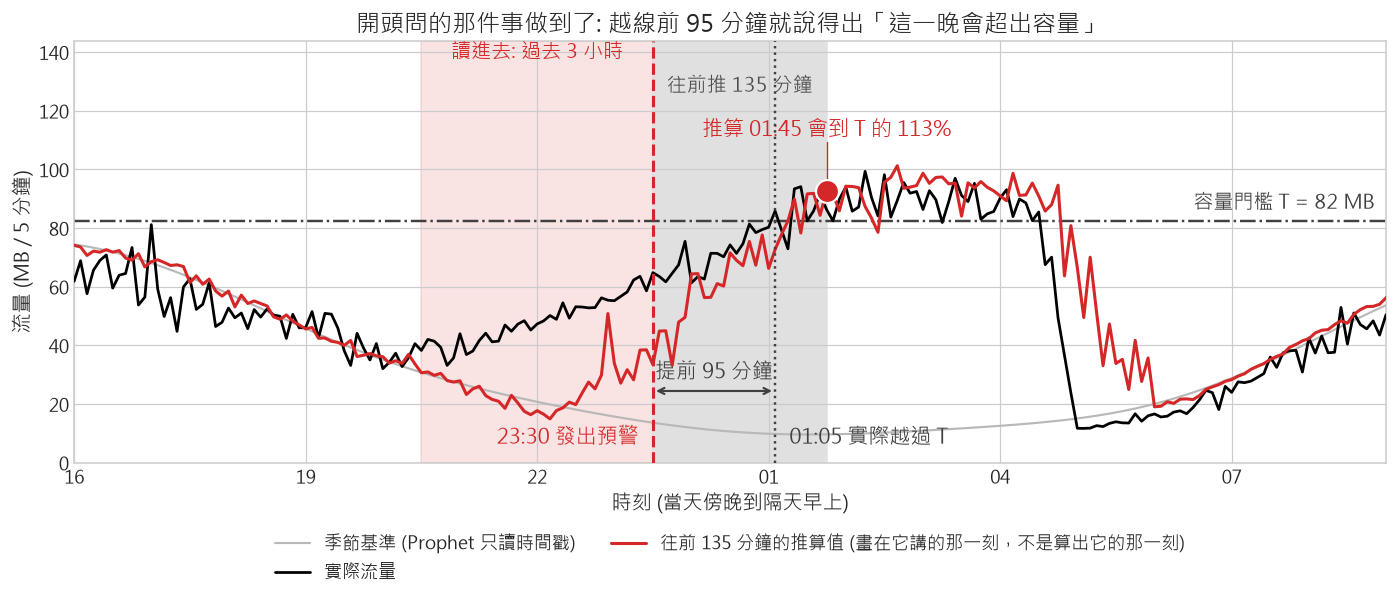

In [17]:
# 🎯 回到開頭那個問題: 站在發出預警的那一刻，完整的 Prophet + XGBoost 看到什麼。
#    這一格不重算任何模型，只從 ALL_G 裡挑出異常事件那一晚，把推算值畫在它所講的那一刻。

# ============ ⚙️ 可調參數 ============
CASE_NIGHT = "2026-02-26"    # 要畫哪一天。換成 2026-02-25 (良性夜、整晚不預警) 的話，
                             # 底下 fire = ... .iloc[0] 會取不到任何一列而報 IndexError
LOOKBACK_H = 3.0             # 圖上「讀進去」那塊底色畫多寬 (小時)。只影響畫面，不影響數字
# ====================================

# ---- 1. 取這一晚的資料。推算值另外取一段，因為它要往右挪 H_MIN 分鐘 ----
#         每一列的 proj 是站在 ds 算出來的，講的卻是 ds + H_MIN 那一刻，所以畫的時候 x 要加上
#         H_MIN: 同一條垂直線切下去兩邊是同一個時鐘時間，推算值準不準才看得出來。
#         來源多讀前面 H_MIN 分鐘的列，挪完圖的左半邊才不會空一段; 右邊多出來的那一段超出
#         night_axis 設定的 xlim，會自己被切掉。
g_case = ALL_G[PRIMARY_PORT]
a_case = pd.Timestamp(CASE_NIGHT) + pd.Timedelta(hours=VIEW_START_HOUR)
b_case = a_case + pd.Timedelta(hours=VIEW_HOURS)
w_case = g_case[(g_case.ds >= a_case) & (g_case.ds <= b_case)].copy()
w_case["h"] = (w_case.ds - a_case).dt.total_seconds() / 3600.0
w_proj = g_case[(g_case.ds >= a_case - pd.Timedelta(minutes=H_MIN))
                & (g_case.ds <= b_case)].copy()
w_proj["h_out"] = (w_proj.ds - a_case).dt.total_seconds() / 3600.0 + H_MIN / 60

# ---- 2. 兩個時刻都從資料裡撈，不寫死。兩個都從 20:00 起算，白天的尖峰不算 ----
night = w_case[w_case.h >= RAMP_H]
fire = night[night.alert.values].iloc[0]        # 這一晚第一次發出預警的那一列
cross = night[night.y >= T_CASE].iloc[0]        # 這一晚實際第一次越過 T
h_fire, h_cross = float(fire.h), float(cross.h)
h_out = h_fire + H_MIN / 60                     # 發出預警那一刻的推算值，講的是這個時刻
ts_out = fire.ds + pd.Timedelta(minutes=H_MIN)
lead_min = int((cross.ds - fire.ds).total_seconds() // 60)   # 提前量: 兩條垂直線之間的距離

# ---- 3. 先底色，再參考線，最後才畫資料。後畫的蓋在上面，順序反了就會被遮住 ----
fig, ax = plt.subplots(figsize=(12.8, 5.6), dpi=110)
# 上緣拉到整晚最高值的 1.42 倍，說明文字才有地方放。實際值與推算值都要納入，不然推算值會頂到頂。
top_y = float(max(w_case.y.max(), w_proj.proj.max())) / 1e6 * 1.42
ax.axvspan(h_fire - LOOKBACK_H, h_fire, color=ACC, alpha=0.13, zorder=0)   # 讀進去的視窗
ax.axvspan(h_fire, h_out, color="0.88", zorder=0)                          # 往前推的跨度
ax.axhline(T_CASE / 1e6, color=INK, ls="-.", lw=1.6, zorder=2)
ax.axvline(h_fire, color=ACC, lw=2.0, ls="--", zorder=6)     # 系統送出通知的時刻
ax.axvline(h_cross, color=INK, lw=1.6, ls=":", zorder=6)     # 流量實際越過 T 的時刻
ax.plot(w_case.h, w_case.yhat / 1e6, color="0.72", lw=1.4, zorder=3,
        label="季節基準 (Prophet 只讀時間戳)")
ax.plot(w_case.h, w_case.y / 1e6, color="black", lw=1.8, zorder=4, label="實際流量")
ax.plot(w_proj.h_out, w_proj.proj / 1e6, color=ACC, lw=2.0, zorder=5,
        label=f"往前 {H_MIN} 分鐘的推算值 (畫在它講的那一刻，不是算出它的那一刻)")
# 大圓點: 發出預警那一刻算出來的那一個推算值，落在它講的 ts_out 上，不是落在預警那條虛線上。
ax.plot([h_out], [fire.proj / 1e6], marker="o", ms=15, color=ACC, zorder=7,
        markeredgecolor="white", markeredgewidth=1.4)

# ---- 4. 文字。每一段的高度都寫成 top_y 的比例，換一天畫也不會壓到資料 ----
ax.set_ylim(0, top_y)
ax.text(h_fire - LOOKBACK_H / 2, top_y * 0.96, f"讀進去: 過去 {LOOKBACK_H:.0f} 小時",
        ha="center", fontsize=13, color=ACC)
ax.text((h_fire + h_out) / 2, top_y * 0.88, f"往前推 {H_MIN} 分鐘", ha="center",
        fontsize=13, color="0.30")
# 細線把圓點跟它的說明串起來，說明才放得夠高，不會壓到底下的兩條曲線。
ax.plot([h_out, h_out], [fire.proj / 1e6 + top_y * 0.03, fire.proj / 1e6 + top_y * 0.115],
        color=ACC, lw=0.9, zorder=6)
ax.text(h_out, fire.proj / 1e6 + top_y * 0.125,
        f"推算 {ts_out:%H:%M} 會到 T 的 {fire.proj / T_CASE:.0%}",
        ha="center", va="bottom", fontsize=13.5, color=ACC)
# 兩條垂直線之間就是提前量。箭頭畫在低處，那一段時間的曲線都在門檻附近，不會疊到。
y_lead = top_y * 0.17
ax.annotate("", xy=(h_cross, y_lead), xytext=(h_fire, y_lead),
            arrowprops=dict(arrowstyle="<->", color=INK, lw=1.4))
ax.text((h_fire + h_cross) / 2, y_lead + top_y * 0.03, f"提前 {lead_min} 分鐘",
        ha="center", fontsize=13.5, color=INK)
ax.text(h_fire - 0.12, top_y * 0.045, f"{fire.ds:%H:%M} 發出預警 ", ha="right", fontsize=13.5,
        color=ACC)
ax.text(h_cross + 0.12, top_y * 0.045, f" {cross.ds:%H:%M} 實際越過 T", fontsize=13.5, color=INK)
ax.text(VIEW_HOURS - 0.15, T_CASE / 1e6 + top_y * 0.03,
        f"容量門檻 T = {T_CASE / 1e6:.0f} MB", ha="right", fontsize=13, color=INK)
night_axis(ax)
ax.set_xlabel("時刻 (當天傍晚到隔天早上)", fontsize=13)
ax.set_ylabel("流量 (MB / 5 分鐘)", fontsize=13)
ax.tick_params(labelsize=11.5)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2, fontsize=11.5,
          framealpha=0.96)
ax.set_title(f"開頭問的那件事做到了: 越線前 {lead_min} 分鐘就說得出「這一晚會超出容量」",
             fontsize=15.5)
plt.tight_layout(); show_fig(fig)


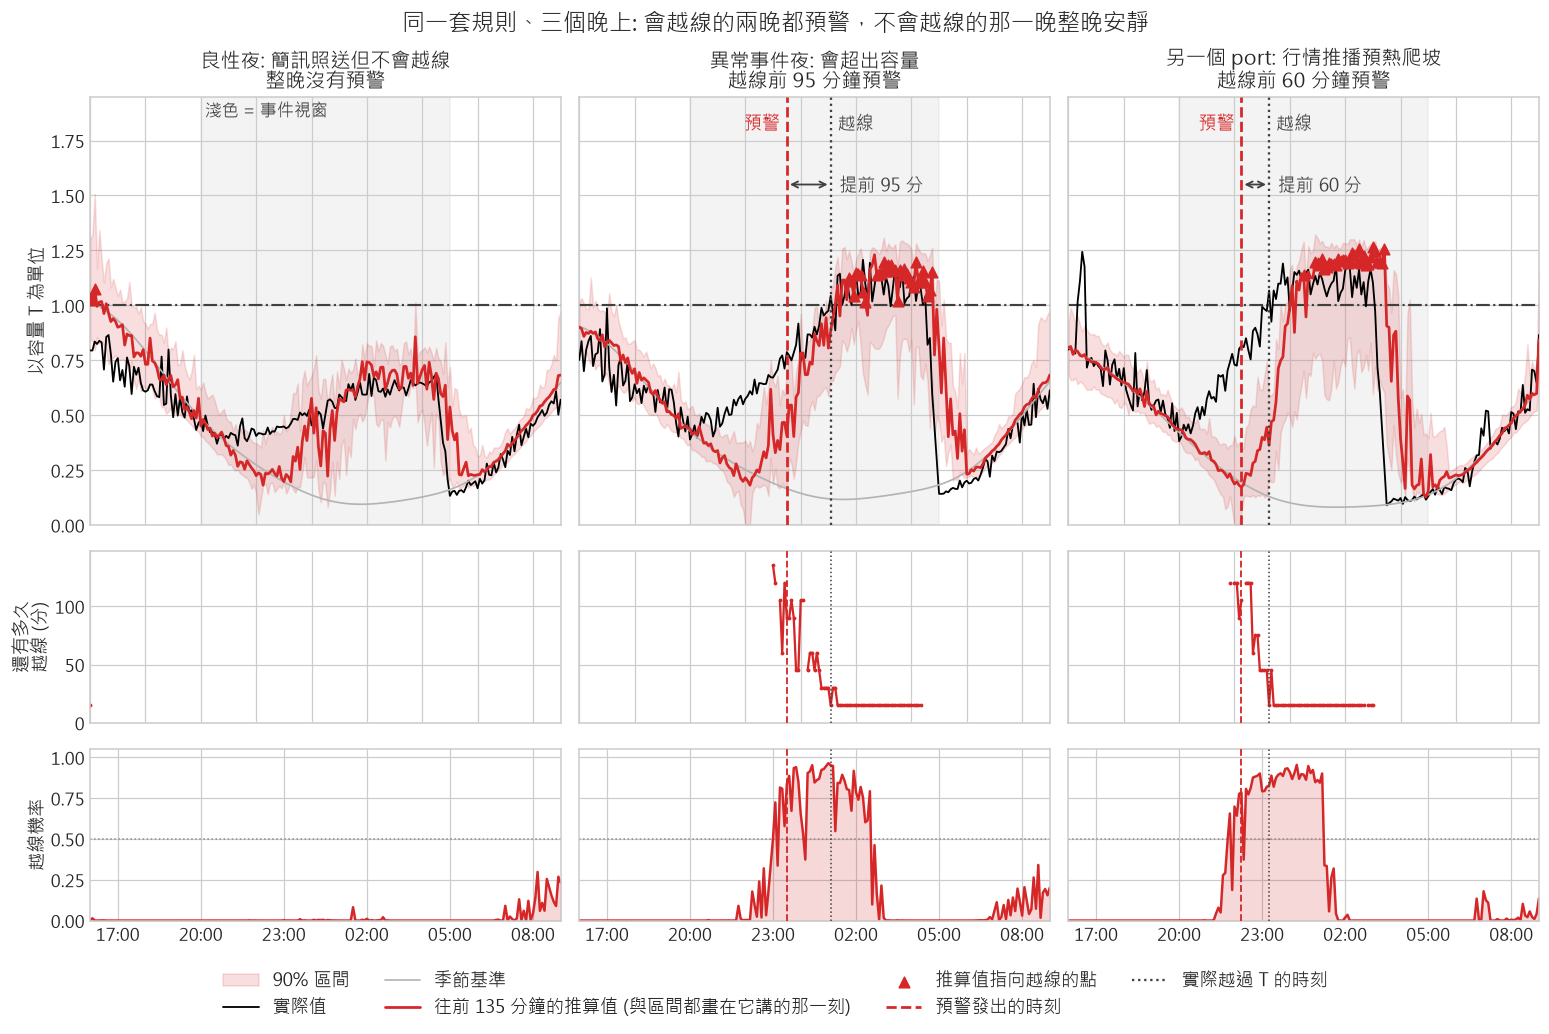

,預警點數 (應為 0),視窗長度 (格)
K_BENIGN 於 port-id7427,0,109
N 於 port-id7430,0,4032


,發出預警的時刻,還有多久越線 (分),越線機率
良性夜: 簡訊照送但不會越線,整晚沒有預警,沒有值,整晚最高 0.08
異常事件夜: 會超出容量,02-26 23:30,90,0.84
另一個 port: 行情推播預熱爬坡,02-24 22:15,105,0.78


In [18]:
# 🎯 同一套規則、三個晚上: 良性的、發生異常事件的、還有另一個 port 上的那一個。

# ============ ⚙️ 可調參數 ============
# PANELS: 要並排比較的三個晚上，一筆是 (port id, 事件視窗開始, 事件視窗結束, 這一欄的標題)。
#   選這三個的理由: 一個預警了就是錯的良性夜、一個真的會越線的異常事件夜，再加一個落在
#   另一個 port、另一個業務、另一個容量門檻上的事故，三個共用同一組模型與設定值。
PANELS = [(PRIMARY_PORT, pd.Timestamp("2026-02-25 20:00"), pd.Timestamp("2026-02-26 05:00"),
           "良性夜: 簡訊照送但不會越線"),
          (PRIMARY_PORT, pd.Timestamp("2026-02-26 20:00"), pd.Timestamp("2026-02-27 05:00"),
           "異常事件夜: 會超出容量"),
          (HELD_PORT, pd.Timestamp("2026-02-24 20:00"), pd.Timestamp("2026-02-25 05:00"),
           "另一個 port: 行情推播預熱爬坡")]
PAD_H = 4        # 事件視窗前後各多畫幾小時。只影響畫出來的範圍，指標一律用事件視窗本身
# ====================================


# ---- 1. 一個晚上的兩個時刻: 系統第一次發出預警、流量實際第一次越過 T ----
#         兩個都只在事件視窗之內找，白天的日間尖峰不算。良性那一晚兩個都找不到，回傳 None。
def panel_times(pid, a, b):
    g = ALL_G[pid]
    ev_w = ((g.ds >= a) & (g.ds <= b)).values
    cross_t = g.loc[ev_w & (g.y >= CAPACITY[pid]).values, "ds"].min()
    alert_t = g.loc[ev_w & g.alert.values, "ds"].min()
    lead = (int((cross_t - alert_t).total_seconds() // 60)
            if pd.notna(alert_t) and pd.notna(cross_t) else None)
    return alert_t, cross_t, lead


# ---- 2. 建圖，然後一欄一個晚上，先畫上排「會不會越線」 ----
#         上排每一個 port 都先除以自己的容量 T，三欄才在同一個尺度上。
#         推算值、它的 90% 區間、預警的三角形一律往右挪 H_MIN 分鐘，畫在它們所講的那一刻;
#         實際值與季節基準畫在自己的時刻。所以同一條垂直線切下去，兩邊講的是同一個時鐘時間。
#         wp 這個遮罩往前多取 H_MIN 分鐘的列，挪完之後左邊才不會空一段。
fig, axes = plt.subplots(3, 3, figsize=(14.2, 8.8), dpi=110, sharey="row",
                         gridspec_kw={"height_ratios": [2.5, 1, 1]})
LEADS = {}
for col, (pid, a, b, ttl) in enumerate(PANELS):
    g = ALL_G[pid]; T = CAPACITY[pid]
    lo, hi = a - pd.Timedelta(hours=PAD_H), b + pd.Timedelta(hours=PAD_H)
    w = ((g.ds >= lo) & (g.ds <= hi)).values
    wp = ((g.ds >= lo - pd.Timedelta(minutes=H_MIN))
          & (g.ds <= hi - pd.Timedelta(minutes=H_MIN))).values
    t_out = g.ds[wp] + pd.Timedelta(minutes=H_MIN)      # 這幾列的推算值講的是哪些時刻
    alert_t, cross_t, lead = panel_times(pid, a, b)
    LEADS[ttl] = lead

    ax = axes[0, col]
    # 事件視窗用淺色標出來。越線時刻與提前量都只在這一段裡面找，白天的尖峰不算,
    # 不畫出來的話，padding 那幾個小時偶爾會有超過 T 的點卻沒有越線標記 (第三欄 16:30
    # 就有四格到 1.24 倍 T) ，看圖的人會以為漏標了。
    ax.axvspan(a, b, color=GREY, alpha=0.10, zorder=0)
    ax.fill_between(t_out, g.proj_lower[wp] / T, g.proj_upper[wp] / T, color=ACC, alpha=0.15,
                    zorder=1, label="90% 區間")
    ax.axhline(1.0, color=INK, ls="-.", lw=1.4, zorder=2)   # y 已經除以 T，門檻就是 1.0
    if lead is not None:
        ax.axvline(alert_t, color=ACC, ls="--", lw=1.8, zorder=5)   # 系統送出通知的時刻
        ax.axvline(cross_t, color=INK, ls=":", lw=1.5, zorder=5)    # 流量實際越過 T 的時刻
    ax.plot(g.ds[w], g.y[w] / T, color="black", lw=1.2, zorder=3, label="實際值")
    ax.plot(g.ds[w], g.yhat[w] / T, color="0.70", lw=1.1, zorder=3, label="季節基準")
    ax.plot(t_out, g.proj[wp] / T, color=ACC, lw=1.8, zorder=4,
            label=f"往前 {H_MIN} 分鐘的推算值 (與區間都畫在它講的那一刻)")
    al = g[wp & g.alert.values]
    # 三角形是「這一格的推算值指向越線」，所以跟著推算值挪; 系統實際出聲的時刻是那條虛線。
    ax.scatter(al.ds + pd.Timedelta(minutes=H_MIN), al.proj / T, s=48, color=ACC, marker="^",
               zorder=6, label="推算值指向越線的點")
    ax.set_ylim(0, 1.95); ax.set_xlim(lo, hi)
    sub = "整晚沒有預警" if lead is None else f"越線前 {lead} 分鐘預警"
    ax.set_title(f"{ttl}\n{sub}", fontsize=13)
    ax.tick_params(labelsize=11, labelbottom=False)
    if lead is not None:
        # 兩條線的標籤與提前量都放在資料上方的空白帶，避開曲線與區間。
        ax.text(alert_t - pd.Timedelta(minutes=15), 1.80, "預警", fontsize=12, color=ACC,
                ha="right")
        ax.text(cross_t + pd.Timedelta(minutes=15), 1.80, "越線", fontsize=12, color=INK,
                ha="left")
        ax.annotate("", xy=(cross_t, 1.55), xytext=(alert_t, 1.55),
                    arrowprops=dict(arrowstyle="<->", color=INK, lw=1.2))
        ax.text(cross_t + pd.Timedelta(minutes=8), 1.55, f" 提前 {lead} 分", va="center",
                ha="left", fontsize=11.5, color=INK)

    # ---- 3. 中排「還有多久越線」與下排「越線機率」，迴圈跑完再補三欄共用的圖例與標題 ----
    #         這兩排讀的都是「站在這一刻」的判讀，所以不挪，畫在自己的時刻上。
    ax2 = axes[1, col]                                      # 中排: 還剩多久會越線
    ax2.plot(g.ds[w], g.tau_min[w], color=ACC, lw=1.5, marker=".", ms=3)
    ax2.set_ylim(0, H_MIN + 12); ax2.set_xlim(lo, hi)
    ax2.tick_params(labelsize=11, labelbottom=False)

    ax3 = axes[2, col]                                      # 下排: 越線機率
    ax3.fill_between(g.ds[w], 0, g.p_exceed[w], color=ACC, alpha=0.18, zorder=1)
    ax3.plot(g.ds[w], g.p_exceed[w], color=ACC, lw=1.6, zorder=2)
    ax3.axhline(0.5, color=GREY, lw=1.0, ls=":", zorder=1)  # 只是一條讀圖的參考線
    ax3.set_ylim(0, 1.05); ax3.set_xlim(lo, hi)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax3.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax3.tick_params(labelsize=11)
    # 兩條垂直線一路畫到下面兩排，一眼看得出預警送出的當下，還有多久越線、機率多高。
    for axx in (ax2, ax3):
        if lead is not None:
            axx.axvline(alert_t, color=ACC, ls="--", lw=1.2, zorder=5)
            axx.axvline(cross_t, color=INK, ls=":", lw=1.0, zorder=5)

axes[0, 0].set_ylabel("以容量 T 為單位", fontsize=12)
axes[0, 0].text(PANELS[0][1], 1.86, " 淺色 = 事件視窗",
                fontsize=11, color=INK, zorder=7)
axes[1, 0].set_ylabel("還有多久\n越線 (分)", fontsize=12)
axes[2, 0].set_ylabel("越線機率", fontsize=12)
h_, l_ = axes[0, 0].get_legend_handles_labels()             # 九張子圖的圖例只畫一次
# 兩條垂直線沒有資料，補兩個只有樣式的圖例項目，圖例才講得完整。
h_ += [plt.Line2D([], [], color=ACC, ls="--", lw=1.8),
       plt.Line2D([], [], color=INK, ls=":", lw=1.5)]
l_ += ["預警發出的時刻", "實際越過 T 的時刻"]
fig.legend(h_, l_, loc="lower center", bbox_to_anchor=(0.5, -0.075), ncol=4, fontsize=11.5,
           framealpha=0.96)
fig.suptitle("同一套規則、三個晚上: 會越線的兩晚都預警，不會越線的那一晚整晚安靜", fontsize=15)
plt.tight_layout(); show_fig(fig)

# ---- 4. 良性對照: 這幾段視窗裡預警了幾點。應該是 0 ----
rows_nc = {}
for ev, p in BENIGN_PAIRS:
    g = ALL_G[p]
    w = ((g.ds >= ev.start_time) & (g.ds <= ev.end_time)).values
    rows_nc[f"{ev.event_id} 於 {p}"] = {
        "預警點數 (應為 0)": int(g.loc[w, "alert"].sum()),
        "視窗長度 (格)": int(w.sum())}
display(pd.DataFrame(rows_nc).T)

# ---- 5. 發出預警的那一刻，三個問題各自的答案 ----
#         同一組模型、同一個時刻，三種說法: 會不會越線、還有多久、機率多高。
rows_q = {}
for pid, a, b, ttl in PANELS:
    g = ALL_G[pid]
    w = ((g.ds >= a) & (g.ds <= b)).values
    al = g[w & g.alert.values]
    if al.empty:                                   # 良性那一晚整晚不預警，看它最高衝到哪
        rows_q[ttl] = {"發出預警的時刻": "整晚沒有預警", "還有多久越線 (分)": "沒有值",
                       "越線機率": f"整晚最高 {g.loc[w, 'p_exceed'].max():.2f}"}
    else:
        r = al.iloc[0]
        rows_q[ttl] = {"發出預警的時刻": f"{r.ds:%m-%d %H:%M}",
                       "還有多久越線 (分)": ("沒有值" if pd.isna(r.tau_min)
                                             else f"{r.tau_min:.0f}"),
                       "越線機率": f"{r.p_exceed:.2f}"}
display(pd.DataFrame(rows_q).T)

## 成功達成 lab6 目標

**兩件都做到了**: 異常事件那晚在越線前預警，前一晚良性的簡訊發送整晚不預警。

| 時刻 | 發生什麼 | 還剩多少時間 |
| --- | --- | --- |
| 20:00 | 月結簡訊大量送出 | 越線前 305 分鐘，殘差跟前一晚重疊 |
| 23:30 | **預警**發出 | **越線前 95 分鐘，前一晚一次都沒預警** |
| 01:05 | 實際越過容量門檻 | 0 |

- **提前量的上限是證據長度，不是選的 horizon**: K 爬升 305 分鐘、M 只有 195 分鐘，提前量 95 分對 60 分。
- **告警持續率是唯一不及格的一列**: 只有四分之三的取樣點在預警，要在 Alert Manager 用維持時間收成一則，交給 Lab 07。
- **分母只有兩個斜坡型事故，穿越門檻很慢**: 95 分鐘要讀成「大約一個半小時」，不是穩的數字。
- **誤警率 0.004 的維運講法**: 平均兩天一則假預警。

---


## 交棒給 RCA

**知道「有事」很容易，知道「會發生異常事件」才是這一章換到的東西。** 兩個晚上的簡訊發送在圖上長得幾乎一樣，一個會越線一個不會; 這一章做出來的規則在會越線的那一晚提前一個多小時發出通知，在不會越線的那一晚一點都不預警。

#### 三件帶得走的事

- **先量兩件事，再挑方法。** 有沒有可以外推的爬升、越線在歷史上有多常見。這份資料上兩晚都會爬升、只有一晚會越線，所以規則的目標從一開始就不是「早」,是「分得出來」
- **模型負責正常，殘差負責不正常。** Prophet 調參數是在讓它學會「這個時刻的正常是多少」; 預警要問的「不正常正在往哪裡走」只在殘差裡，所以這一章的殘差模型只讀殘差自己與時刻
- **任何提前量都要有對照組。** 良性的那一次簡訊發送、無事件的平日、隨機告警器的 chance recall,這三個是同一個動作。沒有對照組的提前量，換一組門檻就能任意變大

還有一句要一起帶回去: 這一章的資料裡刻意注入了一條可以預測的斜坡，而**課程原本那份資料裡的事件量下來十八組有十六組是階梯**,階梯上預警幫不上忙。你們自己的資料是哪一種要自己量。在量到答案之前，導入順序先照最保守的走: 先做殘差監控，再把預警**只掛在會慢慢爬升的容量指標上**。

#### 交棒給 Lab 07

預警換到的時間，只有在你知道要往哪裡查的時候才有價值。這一晚的答案很單純，因為只有一個 port 在動。

下一章換一個問題: **不是「什麼時候會發生異常事件」,是「是誰造成的」。** 場景是盤中，告警畫面上流量翻三倍的那個 port,跟真正的根因不是同一個。

---

## 輸出資料


In [19]:
# 🎯 輸出資料: 寫出三份 CSV 與一份 provenance，Lab 07 與 Grafana 都讀它們。
# 📦 json: 標準庫套件。CSV 只放得下方正的表格，所以設定與出處紀錄 (provenance) 寫成 JSON。
import json

# ============ ⚙️ 可調參數 ============
# RESULT_COLUMNS / CASE_COLUMNS: 這兩份欄名不是這一格自己決定的，它是跟兩個外部設定講好的
#   介面: results_exporter.py (跟這本 notebook 同一層) 與 infra/stack/compose.yaml 裡的
#   RESULT_COLUMNS。被點名的欄位少一個或拼錯一個字母，重播程式會直接 SystemExit，
#   Grafana 上就整片沒有資料。順序也照這份清單，要加欄位就加在最後面，而且三個地方一起改。
#   forecast_30m 與 early_warning_30m 兩個欄名沒有改，但裡面裝的是 H_MIN 分鐘的推算值。
RESULT_COLUMNS = ["timestamp", "device_id", "port_id", "port_role", "event_label", "ml_method",
                  TARGET, "y_hat", "y_hat_lower", "y_hat_upper", "capacity",
                  "forecast_30m", "early_warning_30m",
                  "forecast_positive_anomaly", "forecast_negative_anomaly",
                  "residual", "resid_z", "reactive_alert", "p_exceed", "warning_level",
                  "forecast_risk_score"]
CASE_COLUMNS = ["timestamp", "device_id", "port_id", "port_role", "event_label", "ml_method",
                TARGET, "y_hat", "y_hat_lower", "y_hat_upper", "capacity",
                "forecast_30m", "early_warning_30m", "resid_z",
                "forecast_risk_score", "warning_level_code"]
# 第三份 CSV 的重播窗兩端: 就是前面每一張圖比較的那兩晚 (2/25 良性、2/26 會越線)。
# 只留其中一晚: 重播一輪快一半，但畫面上就沒有「一樣在漲卻不該預警」的對照。
CASE_LO = pd.Timestamp("2026-02-25") + pd.Timedelta(hours=VIEW_START_HOUR)
CASE_HI = pd.Timestamp("2026-02-26") + pd.Timedelta(hours=VIEW_START_HOUR + VIEW_HOURS)
# 風險分數是給 Grafana 排序用的 0 到 100，不是這一章的主線。
#   RISK_SAT: 殘差 z 的飽和點，|z| >= 6 一律算滿分。反應型告警的門檻是 3，取兩倍。
#   RISK_W: 「會不會越線」與「現在偏離多少」的相對比重，兩個加起來是 1。
#   正式環境這三個數字要跟維運一起訂，不要沿用這裡的值。
RISK_SAT, RISK_W = 6.0, 0.6
# ====================================
LEVEL_CODE = {"Info": 0.0, "Watch": 1.0, "Warning": 2.0, "Critical": 3.0}   # 文字換成數字


# ---- 1. 一個 port 一份匯出表，外加一列摘要 ----
def build_port_export(pid):
    """回傳 (照契約排好欄位的整張表, 那個 port 的一列摘要)。"""
    g = ALL_G[pid].copy()
    cap = CAPACITY[pid]

    # 對齊。這個檔案裡同時有兩種方向的欄位，混用會讓 Grafana 上的圖對不起來:
    #   y_hat_lower / y_hat_upper 帶的是「H_MIN 分鐘之前對這一格做出來的預測」(回頭看)，
    #     所以要 .shift(H_STEP) 把它挪到現在這一列，才跟同一列的實際值講同一個時刻;
    #   forecast_30m 帶的是「站在這一格對 H_MIN 分鐘後做出來的預測」(往前看)，所以不挪。
    # 兩個方向搞混是這一段最常出的錯。
    g["y_hat_lower"] = g["proj_lower"].shift(H_STEP)
    g["y_hat_upper"] = g["proj_upper"].shift(H_STEP)
    g["forecast_30m"] = g["proj"]
    g["early_warning_30m"] = g["alert"].astype(int)      # Prometheus 與 Grafana 只吃數字
    # 這兩欄問的是「現在的實際值有沒有掉出 H_MIN 分鐘前畫的那條區間」。
    g["forecast_positive_anomaly"] = (g["y"] > g["y_hat_upper"]).fillna(False).astype(int)
    g["forecast_negative_anomaly"] = (g["y"] < g["y_hat_lower"]).fillna(False).astype(int)
    # 風險分數: 把 p_exceed (會不會越線) 與 react (現在偏離多少) 加權併成一個數字。
    react = np.clip(g["resid_z"].abs() / RISK_SAT, 0, 1)
    g["forecast_risk_score"] = (100 * (RISK_W * g["p_exceed"] + (1 - RISK_W) * react)).round(1)

    # 契約要的五個標示欄裡，device_id / port_role / event_label 不在模型的結果表裡，
    # 要回 features 那張表拿。重播程式會把這五欄變成 Prometheus 的 label (不是數值)。
    meta = (features.loc[features.port_id == pid,
                         ["timestamp", "device_id", "port_id", "port_role", "event_label"]]
            .rename(columns={"timestamp": "ds"}))
    g = g.merge(meta.drop(columns=["port_id"]), on="ds", how="left")
    g["port_id"] = pid
    g["ml_method"] = "prophet+residual-gbm"      # 標示這批數字是哪一條流程算出來的
    g = g.rename(columns={"yhat": "y_hat"})      # 契約的欄名是 y_hat，不是 Prophet 的 yhat
    for c in ("y_hat", "y_hat_lower", "y_hat_upper"):
        g[c] = g[c].clip(lower=0)                # byte 數不可能是負的

    # 摘要: 這個 port 整整 30 天壓成一列。
    scored = g.dropna(subset=["tau_min"])
    summary = {
        "port_id": pid, "device_id": g["device_id"].iloc[0], "port_role": g["port_role"].iloc[0],
        "ml_method": "prophet+residual-gbm", "capacity": round(cap, 1), "horizon_min": H_MIN,
        "time_to_threshold_min": (float(scored["tau_min"].iloc[-1]) if len(scored) else None),
        "max_p_exceed": round(float(g["p_exceed"].max()), 3),
        "reactive_alerts": int(g["reactive_alert"].sum()),
        "early_warnings": int(g["early_warning_30m"].sum()),
        "max_forecast_risk_score": float(g["forecast_risk_score"].max()),
    }
    return g.rename(columns={"ds": "timestamp", "y": TARGET})[RESULT_COLUMNS], summary


# ---- 2. 出口一與出口二: 整個月的逐格結果，以及一個 port 一列的摘要 ----
all_fc, summaries = [], []
for pid in sorted(ALL_G):
    gtab, summ = build_port_export(pid)
    all_fc.append(gtab); summaries.append(summ)
forecast_results = pd.concat(all_fc, ignore_index=True)
# 摘要表照風險分數由大到小排: 最上面那一列就是現在最該先看的 port。
risk_signals = pd.DataFrame(summaries).sort_values("max_forecast_risk_score", ascending=False)
forecast_results.to_csv(DATA_PROCESSED / "forecast_results.csv", index=False)
risk_signals.to_csv(DATA_PROCESSED / "forecast_risk_signals.csv", index=False)

# ---- 3. 出口三: 只裝示範用那兩晚的逐格資料，Grafana 那一段重播的就是這一份 ----
#         直接切 forecast_results，不重算: Grafana 上看到的每一個數字都跟 CSV 裡完全相同。
#         warning_level 是文字，Prometheus 只收數字，所以多寫一欄 warning_level_code。
_m = (forecast_results["timestamp"] >= CASE_LO) & (forecast_results["timestamp"] <= CASE_HI)
forecast_case = forecast_results.loc[_m].copy()
forecast_case["warning_level_code"] = forecast_case["warning_level"].map(LEVEL_CODE)
forecast_case[CASE_COLUMNS].to_csv(DATA_PROCESSED / "forecast_case_K.csv", index=False)

# ---- 4. Provenance: 三個月後有人問「當初這條規則是怎麼配出來的」，要拿著這幾欄重跑 ----
#         多數欄位直接把前面算好的變數印進去，所以改了設定重跑，這份紀錄會自己跟著變。
#         少數是手打的文字 (門檻的算式、反應型的 z 門檻)，改了那幾格要回來改這裡。
provenance = {
    "資料來源": str((DATA_SYNTHETIC / "synthetic_rrd_metrics_week6.csv").relative_to(PROJECT_ROOT)),
    "資料版本": f"{len(features):,} 列，{features.timestamp.min():%Y-%m-%d} 起 "
                f"{(features.timestamp.max() - features.timestamp.min()).days + 1} 天，"
                f"{len(event_catalog)} 個目錄事件",
    "訓練資料期間": f"{PORT_FRAMES[PRIMARY_PORT].ds.min():%Y-%m-%d} 到 {TRAIN_END:%Y-%m-%d} (不含)",
    "轉換與聚合": "RRD 累積計數器 -> Lab 01 語意特徵 -> 5 分鐘取樣",
    "季節基準": f"Prophet daily fo={DAILY_FO} / weekly fo={BEST_FO}, cps=0.05，"
                f"已知排程走 add_regressor，夜間大量傳檔 {sorted(BULK_TRANSFER_KINDS)} "
                f"不當 regressor 且其時段不進訓練集，事件目錄不進模型",
    "殘差模型": f"HistGradientBoosting，五個 port 依各自容量正規化後疊在一起訓練 "
                f"({N_TRAIN:,} 列 x {len(FEAT_NAMES)} 特徵)，{N_SEEDS} 個種子取平均；"
                f"特徵只有殘差自己的近期水準與變化量加時刻的 sin/cos，不讀任何語意指標；"
                f"區間走分位數迴歸 q={QLO}/{QHI}，p_exceed 由這兩個邊界換算標準差"
                f"再算 (該步有常態假設)",
    "告警規則": f"預測型 = 連續 {N_CONSEC} 格 proj(t, {H_MIN}m) >= T; "
                f"反應型 = 殘差穩健 z 門檻 {RESID_Z} 連續 {RESID_K} 格",
    "門檻版本": f"capacity = 該 port 訓練期的 {CAP_Q:.0%} 百分位 x {CAP_MULT}",
    "預測產生時間": f"{pd.Timestamp.now():%Y-%m-%d %H:%M}",
}
with open(DATA_PROCESSED / "forecast_provenance.json", "w", encoding="utf-8") as f:
    json.dump(provenance, f, ensure_ascii=False, indent=2)

# ---- 5. 寫出去了什麼 ----
display(pd.DataFrame({"寫出去的檔案": {
    "forecast_results.csv": f"{len(forecast_results):,} 列、{forecast_results.shape[1]} 欄",
    "forecast_risk_signals.csv": f"{len(risk_signals)} 列 (一個 port 一列)",
    "forecast_case_K.csv": f"{len(forecast_case):,} 列，"
                           f"{CASE_LO:%m-%d %H:%M} 到 {CASE_HI:%m-%d %H:%M}，"
                           f"{len(CASE_COLUMNS)} 欄 (4_grafana.py 起的重播服務讀它)",
    "forecast_provenance.json": f"{len(provenance)} 欄設定與出處紀錄",
    "存放位置": str(DATA_PROCESSED.relative_to(PROJECT_ROOT))}}))
display(risk_signals.set_index("port_id"))
display(pd.DataFrame({"Provenance": provenance}))


,寫出去的檔案
forecast_results.csv,"43,200 列、21 欄"
forecast_risk_signals.csv,5 列 (一個 port 一列)
forecast_case_K.csv,"2,465 列，02-25 16:00 到 02-27 09:00，16 欄 (4_grafana.py 起的重播服務讀它)"
forecast_provenance.json,9 欄設定與出處紀錄
存放位置,outputs\workshop


,device_id,port_role,ml_method,capacity,horizon_min,time_to_threshold_min,max_p_exceed,reactive_alerts,early_warnings,max_forecast_risk_score
port_id,,,,,,,,,,
port-id7427,edge-fw-01,wan-primary,prophet+residual-gbm,82273841.6,135,45.0,0.994,427,72,97.9
port-id7429,core-sw-01,server-uplink,prophet+residual-gbm,121093687.6,135,15.0,0.972,307,32,97.2
port-id7431,dist-sw-02,backup-storage,prophet+residual-gbm,63314787.8,135,15.0,0.937,397,1,96.2
port-id7428,edge-fw-01,wan-secondary,prophet+residual-gbm,24953975.6,135,90.0,0.920,1025,61,95.2
port-id7430,core-sw-01,office-vlan,prophet+residual-gbm,41043457.6,135,15.0,0.911,528,70,94.7


,Provenance
資料來源,data\synthetic\synthetic_rrd_metrics_week6.csv
資料版本,"43,200 列，2026-02-01 起 30 天，17 個目錄事件"
訓練資料期間,2026-02-01 到 2026-02-24 (不含)
轉換與聚合,RRD 累積計數器 -> Lab 01 語意特徵 -> 5 分鐘取樣
季節基準,"Prophet daily fo=4 / weekly fo=10, cps=0.05，已知排程走 add_regressor，夜間大量傳檔 ['desktop_backup', 'partner_file_exchange'] 不當 regressor 且其時段不進訓練集，事件目錄不進模型"
殘差模型,"HistGradientBoosting，五個 port 依各自容量正規化後疊在一起訓練 (32,760 列 x 13 特徵)，5 個種子取平均；特徵只有殘差自己的近期水準與變化量加時刻的 sin/cos，不讀任何語意指標；區間走分位數迴歸 q=0.05/0.95，p_exceed 由這兩個邊界換算標準差再算 (該步有常態假設)"
告警規則,"預測型 = 連續 4 格 proj(t, 135m) >= T; 反應型 = 殘差穩健 z 門檻 3.0 連續 2 格"
門檻版本,capacity = 該 port 訓練期的 97% 百分位 x 1.05
預測產生時間,2026-08-20 22:52
